# **PORTAFOLIOS OPTIMOS**

## **1. INSTALACIÓN Y IMPORTACIÓN DE LIBRERÍAS - CONEXIÓN A GOOGLE SHEETS**

In [1]:
# ==============================================================================
# INSTALACIÓN DE LIBRERÍAS
# ==============================================================================
!pip install yfinance gspread gspread-dataframe --upgrade --quiet

# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
import io
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as sco
import statsmodels.api as sm
import ipywidgets as widgets

from google.colab import auth
from google.auth import default
from gspread_dataframe import set_with_dataframe
from scipy.stats import skew, kurtosis
from IPython.display import display, clear_output
from google.colab import output
output.enable_custom_widget_manager()

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import gspread
from joblib import Parallel, delayed

plt.style.use('seaborn-v0_8-darkgrid')

# ==============================================================================
# CONEXIÓN A GOOGLE SHEETS
# ==============================================================================
print("Solicitando credenciales de Google...")
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
print("¡Conexión con Google Sheets establecida exitosamente!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 2.4 MB/s eta 0:00:00
Solicitando credenciales de Google...
¡Conexión con Google Sheets establecida exitosamente!


## **2. PARÁMETROS GLOBALES Y FUNCIONES REUTILIZABLES**

In [2]:
# ==============================================================================
# PARÁMETROS GLOBALES
# ==============================================================================
DIAS_TRADING      = 252
PERIODO_HISTORICO = "3y"
NOMBRE_SHEET      = "Resultados_TFM_SP500"
SIMS_MONTE_CARLO  = 3000
SIMS_POR_ACTIVO   = 200    # vectorizado: 200 × num_activos es suficiente para la frontera

# ==============================================================================
# FUNCIONES REUTILIZABLES
# ==============================================================================

def rendimiento_portafolio(pesos, ret_medios, mat_cov, dias=DIAS_TRADING):
    """Calcula retorno y volatilidad anualizados de un portafolio."""
    retorno     = np.sum(ret_medios * pesos) * dias
    volatilidad = np.sqrt(np.dot(pesos.T, np.dot(mat_cov, pesos))) * np.sqrt(dias)
    return volatilidad, retorno

def sharpe_negativo(pesos, ret_medios, mat_cov, tasa_libre_riesgo=0):
    """Función objetivo: Sharpe negativo para minimizar (= maximizar Sharpe)."""
    p_vol, p_ret = rendimiento_portafolio(pesos, ret_medios, mat_cov)
    return -(p_ret - tasa_libre_riesgo) / p_vol if p_vol > 0 else 0

def optimizar_portafolio(ret_medios, mat_cov):
    """Ejecuta la optimización SLSQP para maximizar el Ratio de Sharpe."""
    num_activos    = len(ret_medios)
    restricciones  = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    limites        = tuple((0.0, 1.0) for _ in range(num_activos))
    pesos_iniciales = [1.0 / num_activos] * num_activos
    return sco.minimize(
        sharpe_negativo, pesos_iniciales,
        args=(ret_medios, mat_cov),
        method='SLSQP', bounds=limites, constraints=restricciones
    )

def calcular_beta(retornos_portafolio, retornos_mercado):
    """Calcula Beta via regresión OLS (CAPM)."""
    df = pd.DataFrame({'P': retornos_portafolio, 'M': retornos_mercado}).dropna()
    if len(df) < 30:
        return np.nan
    modelo = sm.OLS(df['P'], sm.add_constant(df['M'])).fit()
    return modelo.params['M']

def exportar_a_sheet(spreadsheet, df, nombre_pestana, max_filas=50_000):
    """
    Si el DataFrame supera max_filas lo trunca y avisa.
    Para tablas grandes usa exportar_csv_a_drive() en su lugar.
    """
    filas_orig = len(df)
    if filas_orig > max_filas:
        df = df.head(max_filas)
        print(f"   ⚠️  '{nombre_pestana}': {filas_orig} filas → truncado a {max_filas} para respetar límite de Sheets.")

    celdas = (len(df) + 1) * len(df.columns)   # +1 por encabezado
    if celdas > 9_000_000:
        print(f"   ⛔ '{nombre_pestana}' excede el límite de celdas ({celdas:,}). Exportando como CSV a Drive en su lugar.")
        exportar_csv_a_drive(df, f"{nombre_pestana}.csv")
        return

    try:
        ws = spreadsheet.worksheet(nombre_pestana)
        ws.clear()
    except gspread.exceptions.WorksheetNotFound:
        ws = spreadsheet.add_worksheet(
            title=nombre_pestana,
            rows=str(len(df) + 100),
            cols=str(len(df.columns) + 5)
        )
    set_with_dataframe(ws, df, include_index=False)
    print(f"   ✓ '{nombre_pestana}' → {len(df)} registros exportados ({celdas:,} celdas).")

def exportar_csv_a_drive(df, nombre_archivo):
    """
    Guarda un DataFrame como CSV en Google Drive (para tablas grandes).
    Requiere que Drive esté montado o lo monta automáticamente.
    """
    try:
        from google.colab import drive as _drive
        if not os.path.exists('/content/drive/MyDrive'):
            _drive.mount('/content/drive')
        ruta = f"/content/drive/MyDrive/{nombre_archivo}"
        df.to_csv(ruta, index=False, encoding='utf-8-sig')
        print(f"   ✓ CSV guardado en Drive: {nombre_archivo}  ({len(df):,} filas)")
    except Exception as e:
        # Fallback: guardar en la sesión temporal de Colab
        df.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')
        print(f"   ✓ CSV guardado en sesión local: {nombre_archivo}  ({len(df):,} filas) — Error Drive: {e}")

def descargar_precios(tickers, periodo=PERIODO_HISTORICO):
    """Descarga precios de cierre ajustados y devuelve DataFrame."""
    raw = yf.download(tickers, period=periodo, progress=False)
    df  = raw['Close'] if 'Close' in raw else raw
    if isinstance(df, pd.Series):
        df = df.to_frame(name=tickers[0] if isinstance(tickers, list) else tickers)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(-1)
    return df

# ==============================================================================
# OBTENCIÓN DE TICKERS Y METADATOS DEL S&P 500
# ==============================================================================
print("Descargando lista de tickers y metadatos del S&P 500 desde Wikipedia...\n")

url_wiki = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers  = {'User-Agent': 'Mozilla/5.0'}
tablas   = pd.read_html(io.StringIO(requests.get(url_wiki, headers=headers).text))

# Procesar la tabla de Wikipedia para extraer los metadatos directamente
df_wiki = tablas[0].copy()
df_wiki['Symbol'] = df_wiki['Symbol'].apply(lambda x: str(x).replace('.', '-'))

# Crear diccionarios de mapeo para evitar consultar .info de yfinance individualmente
mapeo_sectores = dict(zip(df_wiki['Symbol'], df_wiki['GICS Sector']))
mapeo_nombres  = dict(zip(df_wiki['Symbol'], df_wiki['Security']))

tickers_sp500 = df_wiki['Symbol'].tolist()
print(f"✓ {len(tickers_sp500)} tickers identificados y vinculados correctamente con su Sector y Nombre.")

Descargando lista de tickers y metadatos del S&P 500 desde Wikipedia...

✓ 503 tickers identificados y vinculados correctamente con su Sector y Nombre.


## **3. ANÁLIS S&P 500**

In [3]:
import yfinance as yf

# ==============================================================================
# DESCARGA DE DATOS Y CÁLCULO DE MÉTRICAS INDIVIDUALES
# ==============================================================================
print(f"\nDescargando historial de {len(tickers_sp500)} tickets (período: {PERIODO_HISTORICO})...")
print("Esto puede tardar varios minutos...")

df_precios_sp500  = descargar_precios(tickers_sp500)
df_retornos_sp500 = df_precios_sp500.pct_change(fill_method=None).dropna()

print("Descargando Benchmark (^GSPC) para CAPM...\n")
gspc_raw         = yf.download('^GSPC', period=PERIODO_HISTORICO, progress=False)['Close']
retornos_mercado = gspc_raw.pct_change(fill_method=None).dropna()
if isinstance(retornos_mercado, pd.DataFrame):
    retornos_mercado = retornos_mercado.iloc[:, 0]
retornos_mercado.name = 'Mercado'

print("Calculando métricas individuales (Retorno, Volatilidad, Sharpe, Beta, Sector)...")
metricas_lista = []

for i, ticker in enumerate(tickers_sp500):
    try:
        # SOLUCIÓN: Obtenemos sector y nombre desde los mapas en memoria de Wikipedia
        # Esto reduce a CERO las peticiones HTTP individuales por activo
        sector = mapeo_sectores.get(ticker, "Desconocido")
        nombre = mapeo_nombres.get(ticker, "Desconocido")

        if ticker not in df_retornos_sp500.columns:
            continue

        serie = df_retornos_sp500[ticker].dropna()
        if serie.empty:
            continue

        ret_anual = serie.mean() * DIAS_TRADING
        vol_anual = serie.std()  * np.sqrt(DIAS_TRADING)
        sharpe    = ret_anual / vol_anual if vol_anual > 0 else 0
        beta      = calcular_beta(serie, retornos_mercado)

        metricas_lista.append({
            "Sector":               sector,
            "Ticker":               ticker,
            "Nombre":               nombre,
            "Retorno Anualizado":   round(ret_anual, 4),
            "Volatilidad (Riesgo)": round(vol_anual, 4),
            "Ratio de Sharpe":      round(sharpe, 4),
            "Beta (CAPM)":          round(beta, 4) if not pd.isna(beta) else "N/A"
        })

        if (i + 1) % 50 == 0:
            print(f"   Progreso: {i + 1}/{len(tickers_sp500)}")

    except Exception:
        continue

df_Metricas = pd.DataFrame(metricas_lista)
df_Metricas = df_Metricas.sort_values(
    ["Sector", "Ratio de Sharpe"], ascending=[True, False]
).reset_index(drop=True)

print(f"\n ✓ Métricas calculadas para {len(df_Metricas)} tickers.")
display(df_Metricas)

# ==============================================================================
# MATRIZ DE CORRELACIÓN
# ==============================================================================
print("Calculando matriz de correlación...")
tickers_corr = df_retornos_sp500.columns.tolist()
df_corr_completa = df_retornos_sp500[tickers_corr].corr()
print(f"✓ Correlación calculada: {len(tickers_corr)} × {len(tickers_corr)} tickers.")

# ==============================================================================
# SEGMENTACIÓN K-MEANS — PERFILES DE RIESGO/RETORNO
# ==============================================================================
print("\n[K-Means] Segmentando activos por perfil de inversión...")

df_features     = df_Metricas[["Retorno Anualizado", "Volatilidad (Riesgo)"]].copy()
df_features     = df_features.replace("N/A", np.nan).dropna()
idx_validos     = df_features.index
scaler          = StandardScaler()
features_scaled = scaler.fit_transform(df_features)
kmeans          = KMeans(n_clusters=3, random_state=42, n_init=10)
df_Metricas.loc[idx_validos, "Cluster"] = kmeans.fit_predict(features_scaled)

centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=["Retorno Medio", "Volatilidad Media"]
)
centroides.index.name = "Cluster"
print("\n=== Centroides por Perfil ===\n")
print(centroides)

# ==============================================================================
# OPTIMIZACIÓN: FRONTERA EFICIENTE + PORTAFOLIOS ÓPTIMOS POR SECTOR
# ==============================================================================
print("\n[Optimización] Calculando Frontera Eficiente por Sector...")

mapeo_nombres_sp500 = dict(zip(df_Metricas["Ticker"], df_Metricas["Nombre"]))
sectores_dict       = df_Metricas.groupby("Sector")["Ticker"].apply(list).to_dict()

portafolios_optimos      = []
tabla_pesos_largo        = []
lista_todas_simulaciones = []
sim_ml_por_sector        = {}

sectores_con_datos = {
    sector: tickers
    for sector, tickers in sectores_dict.items()
    if len([t for t in tickers if t in df_retornos_sp500.columns]) >= 2
}

num_sectores   = len(sectores_con_datos)

datos_fe = {}

for idx, (sector, tickers) in enumerate(sectores_con_datos.items()):
    tickers_validos = [t for t in tickers if t in df_retornos_sp500.columns]

    df_ret_sector = (
        df_retornos_sp500[tickers_validos]
        .dropna(how="all")
        .fillna(df_retornos_sp500[tickers_validos].mean())
    )
    tickers_validos = [t for t in tickers_validos if df_ret_sector[t].notna().any()]
    df_ret_sector   = df_ret_sector[tickers_validos]

    if df_ret_sector.shape[1] < 2:
        continue

    ret_medios  = df_ret_sector.mean()
    mat_cov     = df_ret_sector.cov()
    num_activos = len(tickers_validos)

    resultado        = optimizar_portafolio(ret_medios, mat_cov)
    pesos_optimos    = resultado.x
    opt_vol, opt_ret = rendimiento_portafolio(pesos_optimos, ret_medios, mat_cov)
    opt_sharpe       = opt_ret / opt_vol if opt_vol > 0 else 0
    ret_port_sector  = (df_ret_sector * pesos_optimos).sum(axis=1)
    opt_beta         = calcular_beta(ret_port_sector, retornos_mercado)

    portafolios_optimos.append({
        "Sector":               sector,
        "Num_Activos":          num_activos,
        "Retorno Esperado":     round(opt_ret,    4),
        "Volatilidad (Riesgo)": round(opt_vol,    4),
        "Ratio de Sharpe Máx":  round(opt_sharpe, 4),
        "Beta (CAPM)":          round(opt_beta,   4) if not pd.isna(opt_beta) else "N/A"
    })

    for i, t in enumerate(tickers_validos):
        tabla_pesos_largo.append({
            "Sector":   sector,
            "Ticker":   t,
            "Nombre":   mapeo_nombres_sp500.get(t, ""),
            "Peso (%)": round(pesos_optimos[i] * 100, 4)
        })

    resultados_sim = []
    filas_ml       = []

    for ticker_base in tickers_validos:
        for _ in range(SIMS_POR_ACTIVO):
            w = np.random.random(num_activos)
            idx_base     = tickers_validos.index(ticker_base)
            w[idx_base]  = max(w[idx_base], 0.05)
            w           /= np.sum(w)

            p_vol, p_ret = rendimiento_portafolio(w, ret_medios, mat_cov)
            p_sharpe     = p_ret / p_vol if p_vol > 0 else 0

            resultados_sim.append((p_vol, p_ret, p_sharpe))

            fila_completa = {
                "Sector":           sector,
                "Ticker_Base":      ticker_base,
                "Retorno Esperado": round(p_ret,    6),
                "Volatilidad":      round(p_vol,    6),
                "Ratio de Sharpe":  round(p_sharpe, 6)
            }
            for j, t in enumerate(tickers_validos):
                fila_completa[f"Peso_{t}"] = round(w[j] * 100, 4)
            lista_todas_simulaciones.append(fila_completa)

            fila_ml = {t: w[j] for j, t in enumerate(tickers_validos)}
            fila_ml["Sharpe"] = p_sharpe
            filas_ml.append(fila_ml)

    sim_ml_por_sector[sector] = pd.DataFrame(filas_ml)
    arr_sim = np.array(resultados_sim).T

    # Guardar datos para graficar en B13
    datos_fe[sector] = {
        "arr_sim":   arr_sim,
        "opt_vol":   opt_vol,
        "opt_ret":   opt_ret,
        "opt_sharpe": opt_sharpe,
        "num_activos": num_activos
    }

tabla_portafolios_optimos   = pd.DataFrame(portafolios_optimos)
tabla_simulaciones_sectores = pd.DataFrame(lista_todas_simulaciones)
tabla_pesos = (
    pd.DataFrame(tabla_pesos_largo)
    .sort_values(["Sector", "Peso (%)"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\n=== Resumen: Portafolios Óptimos por Sector ===")
display(tabla_portafolios_optimos[["Sector", "Num_Activos", "Retorno Esperado",
                                   "Volatilidad (Riesgo)", "Ratio de Sharpe Máx", "Beta (CAPM)"]])
print(f"\n✓ Pesos calculados: {len(tabla_pesos)} activos en {tabla_pesos['Sector'].nunique()} sectores.")


# ==============================================================================
# PORTAFOLIO CONSOLIDADO — MEJOR ACTIVO POR SECTOR
# ==============================================================================
print("\n[Portafolio Consolidado] Construyendo con el líder de cada sector...")

mejores_por_sector = (
    df_Metricas.sort_values("Ratio de Sharpe", ascending=False)
    .drop_duplicates("Sector")
)
tickers_top    = mejores_por_sector["Ticker"].tolist()
df_ret_top     = df_retornos_sp500[[t for t in tickers_top if t in df_retornos_sp500.columns]].dropna()
tickers_top    = df_ret_top.columns.tolist()
ret_top        = df_ret_top.mean()
cov_top        = df_ret_top.cov()
res_top        = optimizar_portafolio(ret_top, cov_top)
pesos_top      = res_top.x
vol_top, ret_top_val = rendimiento_portafolio(pesos_top, ret_top, cov_top)
sharpe_top     = ret_top_val / vol_top if vol_top > 0 else 0
ret_diario_top = (df_ret_top * pesos_top).sum(axis=1)
beta_top       = calcular_beta(ret_diario_top, retornos_mercado)

print("\n=== Pesos del Portafolio Consolidado ===")
for t, p in zip(tickers_top, pesos_top):
    print(f"  {t}: {p*100:.2f}%")
print(f"\n  Retorno Esperado : {ret_top_val:.4f}")
print(f"  Riesgo (Vol.)    : {vol_top:.4f}")
print(f"  Ratio de Sharpe  : {sharpe_top:.4f}")
print(f"  Beta (CAPM)      : {beta_top:.4f}" if not np.isnan(beta_top) else "  Beta (CAPM): N/A")

# ==============================================================================
# MODELO PREDICTIVO — RANDOM FOREST POR SECTOR
# ==============================================================================
print("\n Entrenando modelos Random Forest por Sector...")

resultados_rf = []

for sector, df_ml in sim_ml_por_sector.items():
    tickers_sector = [c for c in df_ml.columns if c != "Sharpe"]
    X_s = df_ml[tickers_sector]
    y_s = df_ml["Sharpe"]

    if len(X_s) < 50:
        print(f"  {sector:20s} → ⚠️  datos insuficientes ({len(X_s)} sims), omitido.")
        continue

    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
    rf  = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_tr, y_tr)
    r2  = r2_score(y_te, rf.predict(X_te))
    mse = mean_squared_error(y_te, rf.predict(X_te))

    print(f"  {sector:20s} → R²: {r2:.4f} | MSE: {mse:.6e} | Tickers: {len(tickers_sector)}")
    resultados_rf.append({
        "Sector":      sector,
        "Num_Tickers": len(tickers_sector),
        "Num_Sims":    len(X_s),
        "R2_Score":    round(r2, 4),
        "MSE":         round(mse, 8)
    })

tabla_resultados_rf = pd.DataFrame(resultados_rf)
print("\n=== Resumen Modelos Random Forest ===")
display(tabla_resultados_rf)



Descargando historial de 503 tickets (período: 3y)...
Esto puede tardar varios minutos...
Descargando Benchmark (^GSPC) para CAPM...

Calculando métricas individuales (Retorno, Volatilidad, Sharpe, Beta, Sector)...
   Progreso: 50/503
   Progreso: 100/503
   Progreso: 150/503
   Progreso: 200/503
   Progreso: 250/503
   Progreso: 300/503
   Progreso: 350/503
   Progreso: 400/503
   Progreso: 450/503
   Progreso: 500/503

 ✓ Métricas calculadas para 503 tickers.


,Sector,Ticker,Nombre,Retorno Anualizado,Volatilidad (Riesgo),Ratio de Sharpe,Beta (CAPM)
0,Communication Services,WBD,Warner Bros. Discovery,0.5360,0.2272,2.3590,0.3522
1,Communication Services,GOOGL,Alphabet Inc. (Class A),0.6455,0.3056,2.1122,1.3592
2,Communication Services,GOOG,Alphabet Inc. (Class C),0.6234,0.2991,2.0841,1.3305
3,Communication Services,SATS,EchoStar,1.0511,0.5635,1.8651,1.2125
4,Communication Services,VZ,Verizon,0.4140,0.2457,1.6848,-0.2963
...,...,...,...,...,...,...,...
498,Utilities,VST,Vistra Corp.,-0.1757,0.5199,-0.3380,1.4940
499,Utilities,PPL,PPL Corporation,-0.0634,0.1819,-0.3489,-0.0196
500,Utilities,NRG,NRG Energy,-0.3413,0.4732,-0.7213,1.6081
501,Utilities,AWK,American Water Works,-0.1659,0.2262,-0.7335,-0.4023


Calculando matriz de correlación...
✓ Correlación calculada: 503 × 503 tickers.

[K-Means] Segmentando activos por perfil de inversión...

=== Centroides por Perfil ===

         Retorno Medio  Volatilidad Media
Cluster                                  
0            -0.235908           0.425392
1             0.179913           0.263389
2             1.391522           0.592388

[Optimización] Calculando Frontera Eficiente por Sector...

=== Resumen: Portafolios Óptimos por Sector ===


,Sector,Num_Activos,Retorno Esperado,Volatilidad (Riesgo),Ratio de Sharpe Máx,Beta (CAPM)
0,Communication Services,23,0.5225,0.1353,3.8631,0.4348
1,Consumer Discretionary,48,0.6312,0.2074,3.0439,0.8949
2,Consumer Staples,36,0.5123,0.1505,3.4035,0.2824
3,Energy,21,0.9775,0.2368,4.1281,0.0935
4,Financials,76,0.4471,0.1384,3.2305,0.6203
5,Health Care,59,0.6528,0.1689,3.8638,0.4455
6,Industrials,79,0.8118,0.2044,3.9708,0.9742
7,Information Technology,73,1.5859,0.2693,5.8892,1.3932
8,Materials,26,0.8809,0.2128,4.1390,0.6729
9,Real Estate,31,0.5575,0.1572,3.5465,0.5180



✓ Pesos calculados: 503 activos en 11 sectores.

[Portafolio Consolidado] Construyendo con el líder de cada sector...

=== Pesos del Portafolio Consolidado ===
  SNDK: 8.40%
  TRGP: 32.12%
  NUE: 11.99%
  FDX: 6.42%
  HST: 3.16%
  STT: 0.00%
  CASY: 8.94%
  VTRS: 4.83%
  WBD: 13.19%
  ROST: 7.67%
  EIX: 3.28%

  Retorno Esperado : 1.1612
  Riesgo (Vol.)    : 0.1598
  Ratio de Sharpe  : 7.2646
  Beta (CAPM)      : 0.6477

 Entrenando modelos Random Forest por Sector...
  Communication Services → R²: 0.8408 | MSE: 3.034903e-02 | Tickers: 23
  Consumer Discretionary → R²: 0.6230 | MSE: 1.051645e-02 | Tickers: 48
  Consumer Staples     → R²: 0.6760 | MSE: 1.424701e-02 | Tickers: 36
  Energy               → R²: 0.8641 | MSE: 2.251082e-03 | Tickers: 21
  Financials           → R²: 0.5705 | MSE: 1.060204e-02 | Tickers: 76
  Health Care          → R²: 0.6507 | MSE: 2.098432e-02 | Tickers: 59
  Industrials          → R²: 0.5242 | MSE: 1.320440e-02 | Tickers: 79
  Information Technology → R²: 0

,Sector,Num_Tickers,Num_Sims,R2_Score,MSE
0,Communication Services,23,4600,0.8408,0.030349
1,Consumer Discretionary,48,9600,0.6230,0.010516
2,Consumer Staples,36,7200,0.6760,0.014247
3,Energy,21,4200,0.8641,0.002251
4,Financials,76,15200,0.5705,0.010602
5,Health Care,59,11800,0.6507,0.020984
6,Industrials,79,15800,0.5242,0.013204
7,Information Technology,73,14600,0.5868,0.026854
8,Materials,26,5200,0.7227,0.017610
9,Real Estate,31,6200,0.8742,0.008086


## **4. EXPORTACIÓN A GOOGLE SHEETS + DRIVE**

In [4]:
# ==============================================================================
# EXPORTACIÓN A GOOGLE SHEETS + DRIVE
# ==============================================================================
print(f"\n[Export] Exportando a Google Sheets: '{NOMBRE_SHEET}'...")

try:
    sh = gc.open(NOMBRE_SHEET)
except gspread.exceptions.SpreadsheetNotFound:
    sh = gc.create(NOMBRE_SHEET)

df_corr_export = df_corr_completa.reset_index()
df_corr_export = df_corr_export.rename(columns={df_corr_export.columns[0]: "Ticker"})

exportar_a_sheet(sh, df_Metricas,               "Metricas_Individuales_SP500")
exportar_a_sheet(sh, tabla_portafolios_optimos, "Portafolios_Optimos_Sector")
exportar_a_sheet(sh, tabla_pesos,               "Composicion_Pesos_SP500")
exportar_a_sheet(sh, df_corr_export,            "Matriz_Correlacion")
exportar_a_sheet(sh, tabla_resultados_rf,       "Resultados_RandomForest")

sim_resumen = (
    tabla_simulaciones_sectores
    .groupby(["Sector", "Ticker_Base"])[["Retorno Esperado", "Volatilidad", "Ratio de Sharpe"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
    .reset_index()
)
sim_resumen.columns = [
    "_".join(c).strip("_") if c[1] else c[0]
    for c in sim_resumen.columns
]
exportar_a_sheet(sh, sim_resumen, "Simulaciones_Resumen_Ticker")
print("   Exportando simulaciones completas con pesos a Drive...")

exportar_csv_a_drive(tabla_simulaciones_sectores, "Simulaciones_MonteCarlo_Completo.csv")
print(f"   ✓ {len(tabla_simulaciones_sectores):,} simulaciones exportadas.")

print(f"\n✓ Exportación completada. URL: {sh.url}")


[Export] Exportando a Google Sheets: 'Resultados_TFM_SP500'...
   ✓ 'Metricas_Individuales_SP500' → 503 registros exportados (4,032 celdas).
   ✓ 'Portafolios_Optimos_Sector' → 11 registros exportados (72 celdas).
   ✓ 'Composicion_Pesos_SP500' → 503 registros exportados (2,016 celdas).
   ✓ 'Matriz_Correlacion' → 503 registros exportados (254,016 celdas).
   ✓ 'Resultados_RandomForest' → 11 registros exportados (60 celdas).
   ✓ 'Simulaciones_Resumen_Ticker' → 503 registros exportados (7,056 celdas).
   Exportando simulaciones completas con pesos a Drive...
Mounted at /content/drive
   ✓ CSV guardado en Drive: Simulaciones_MonteCarlo_Completo.csv  (100,600 filas)
   ✓ 100,600 simulaciones exportadas.

✓ Exportación completada. URL: https://docs.google.com/spreadsheets/d/1jzXgy-Ec70RLQmXVOsV-oCBhElvBmFKerQxzlqTRS7w


## **5. VISUALIZACIONES**


 Top 20 activos por Ratio de Sharpe...


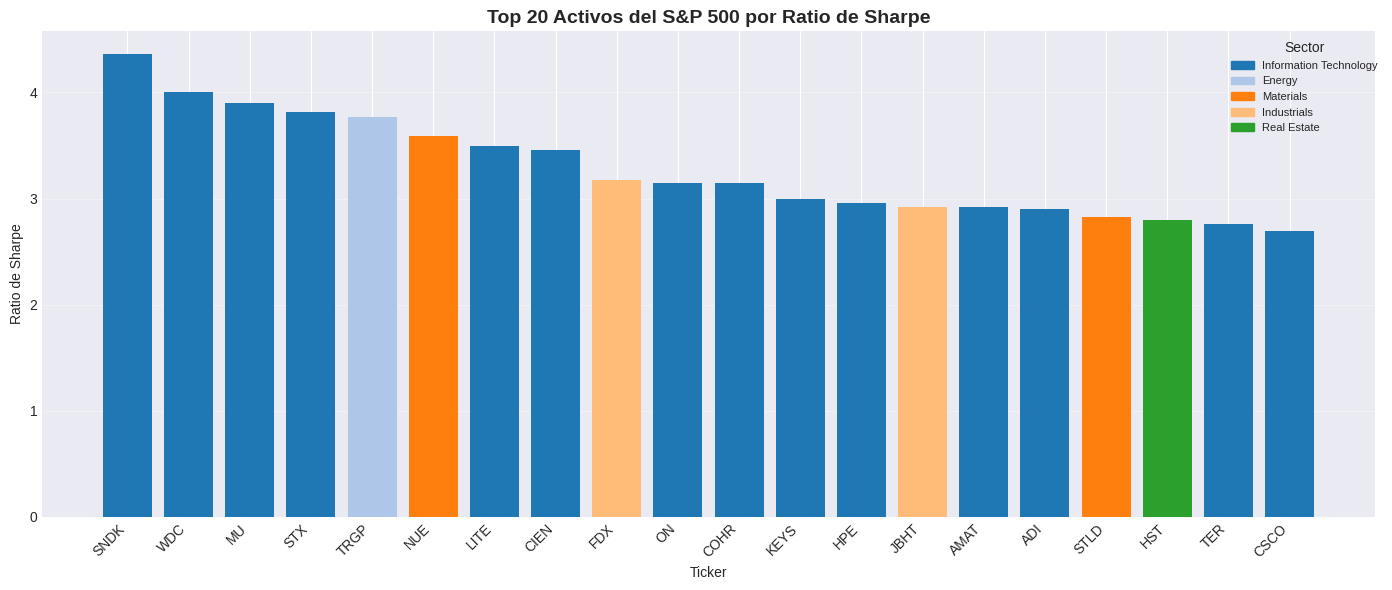


 Fronteras eficientes por sector...


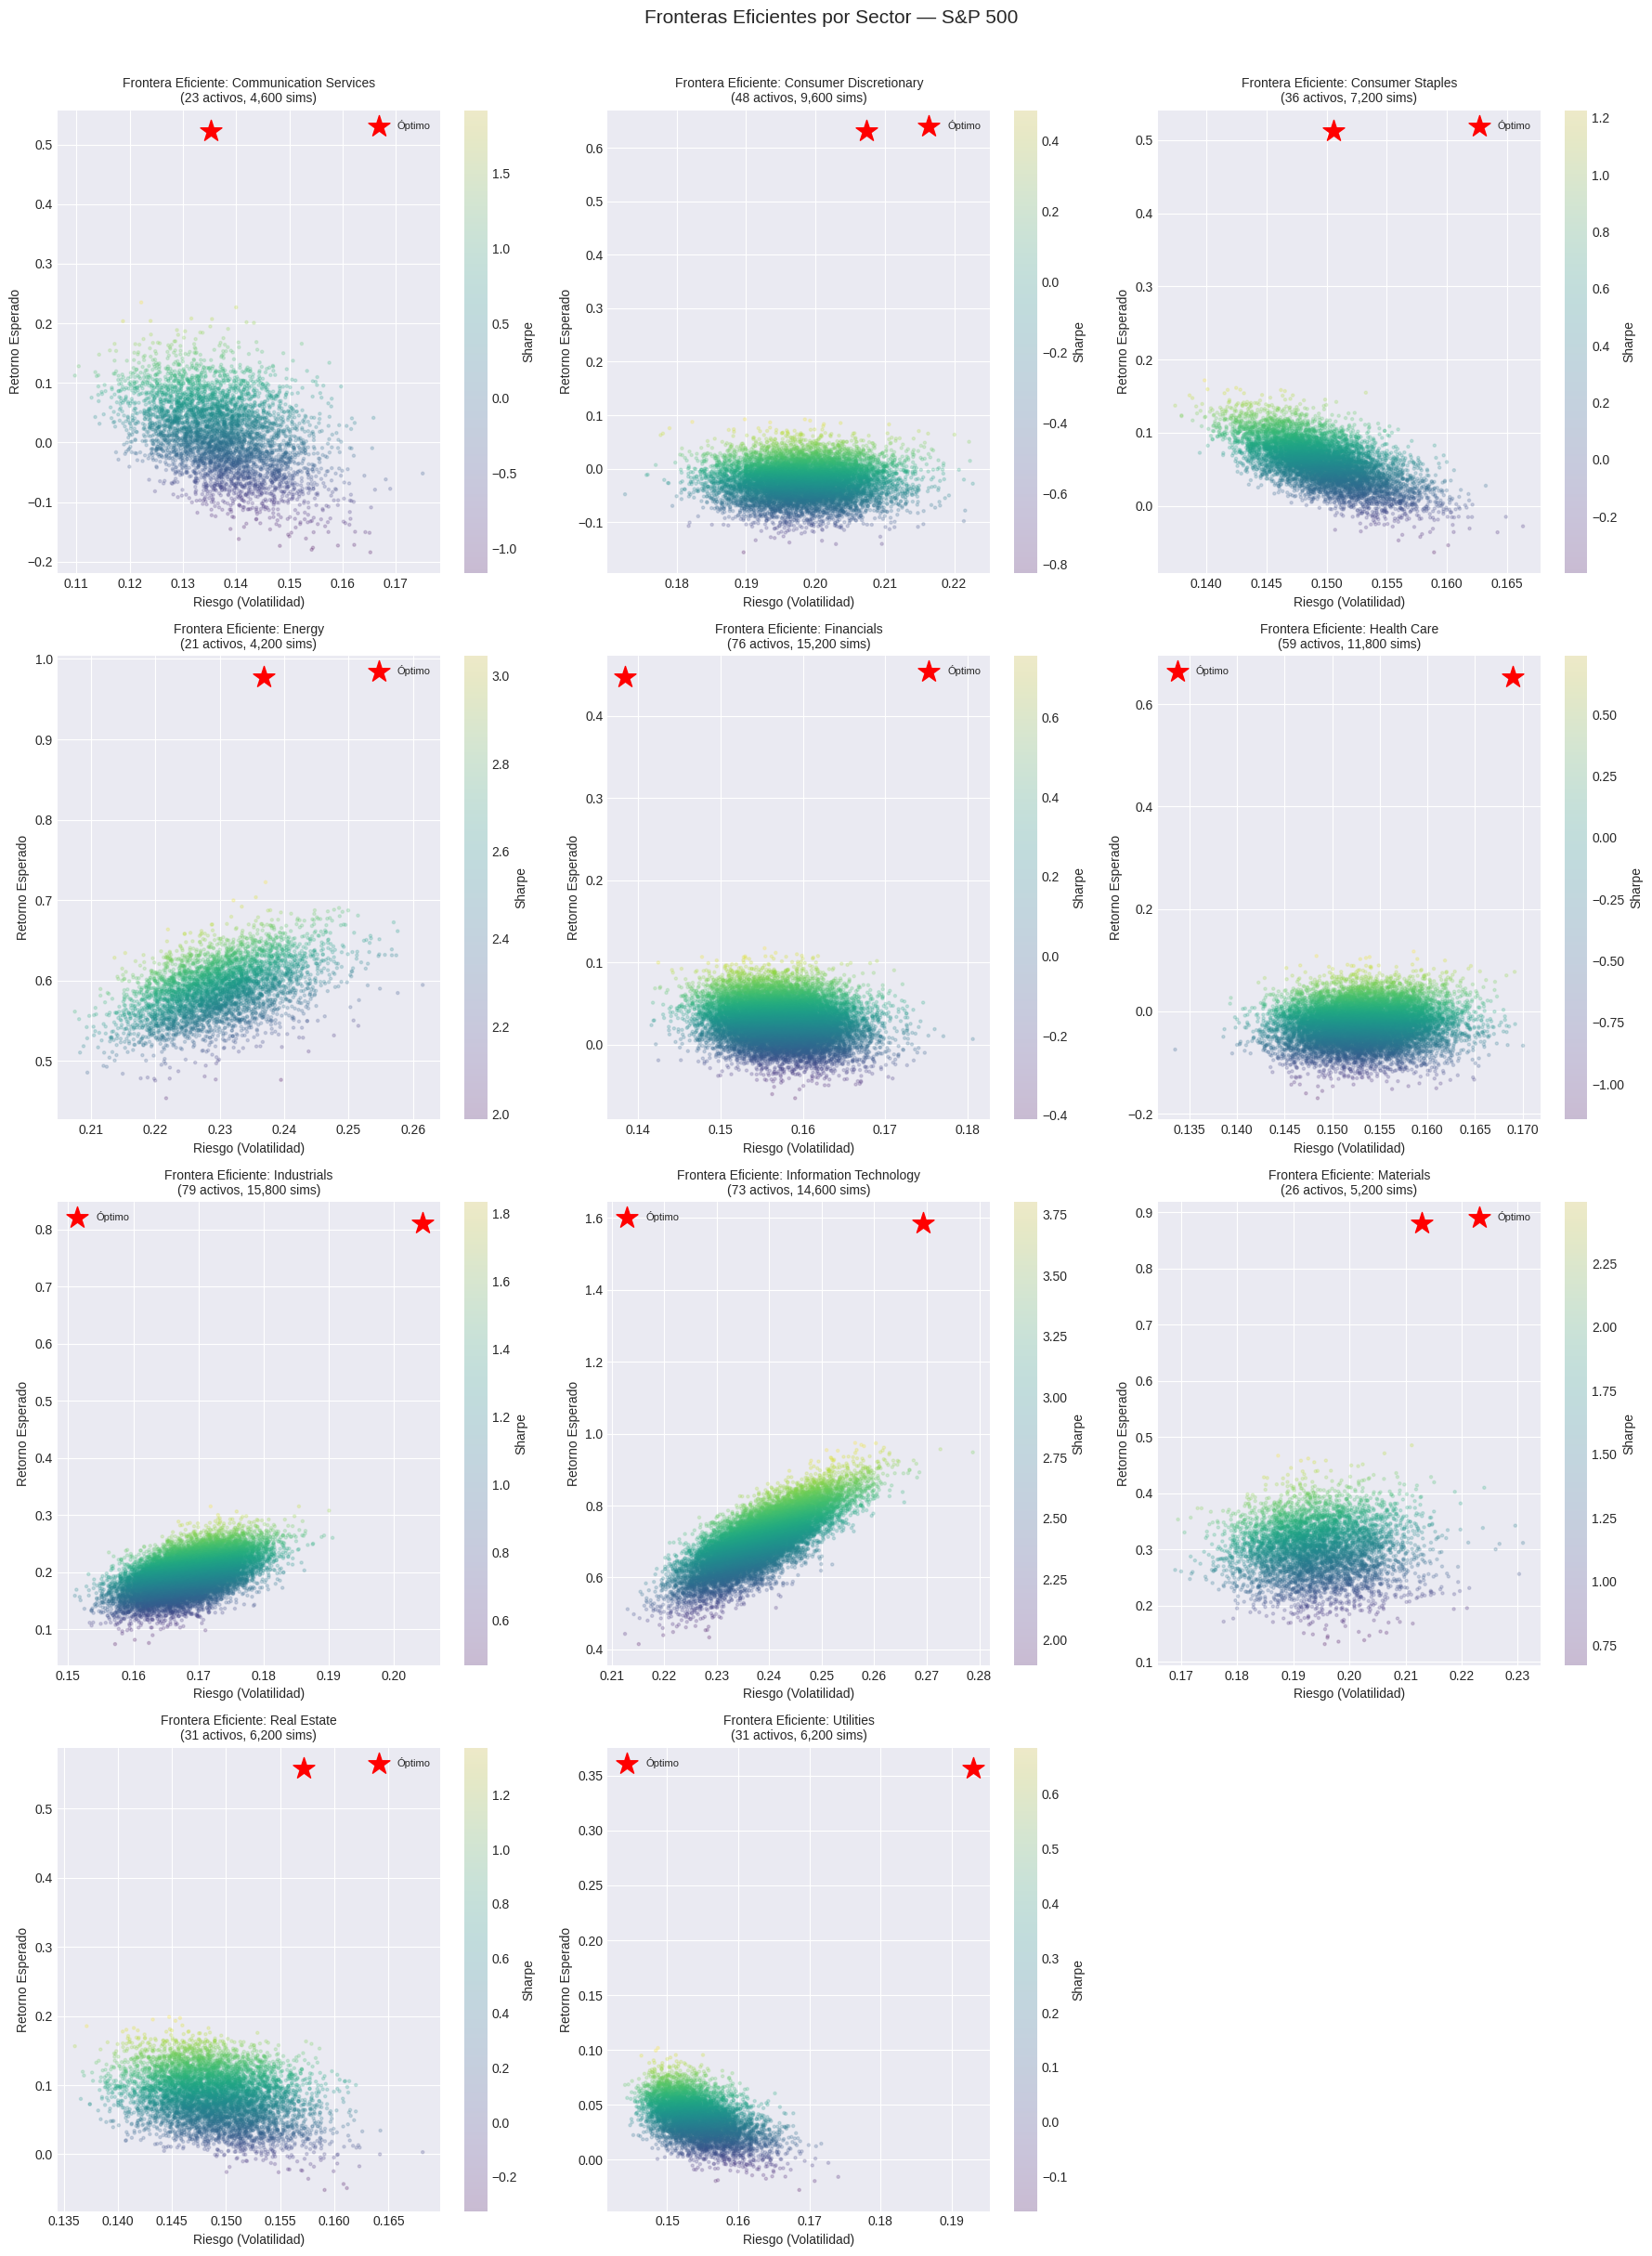


 Evolución histórica de precios...


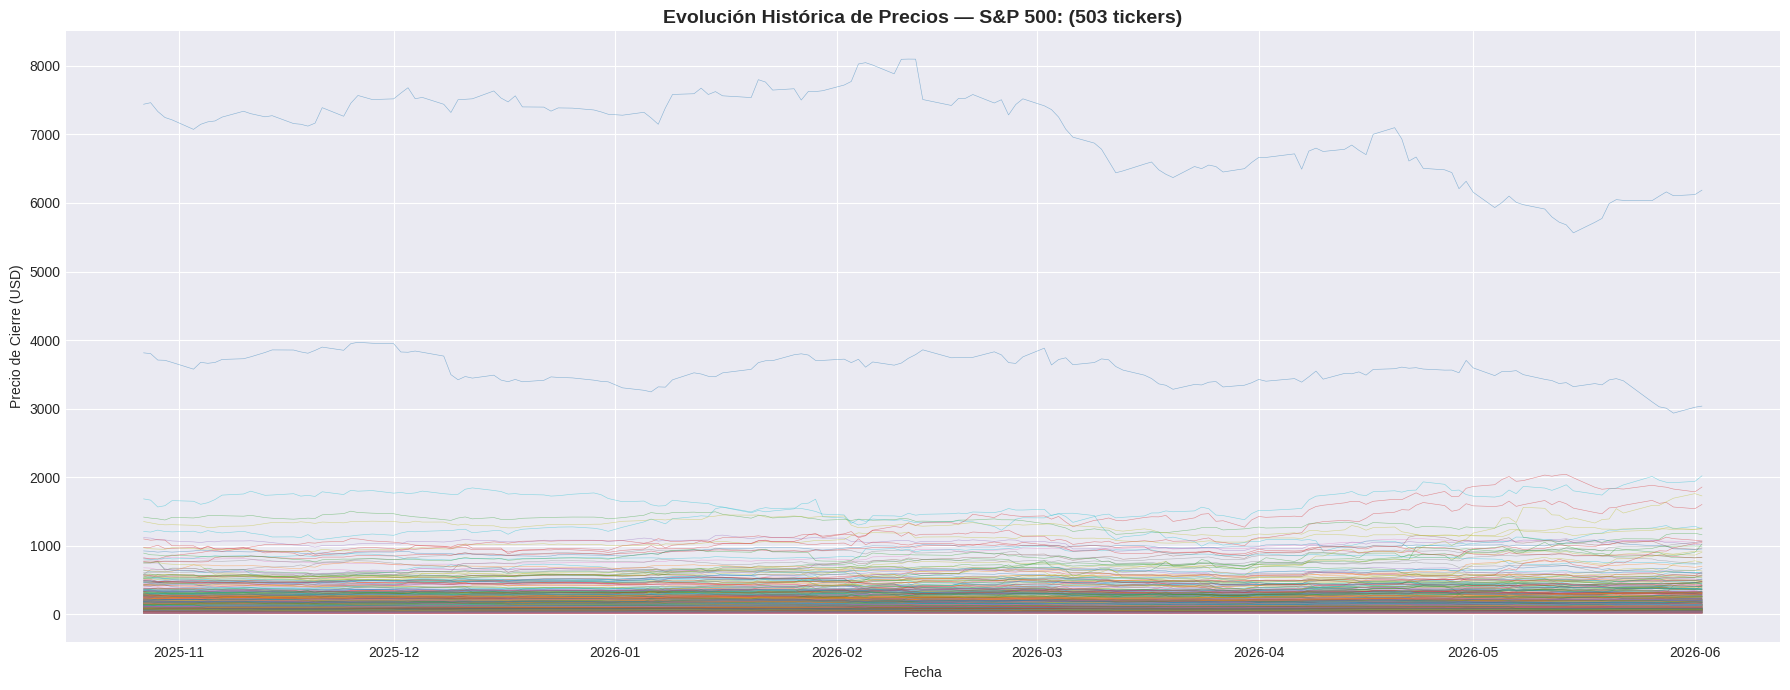


 Distribución de retornos...


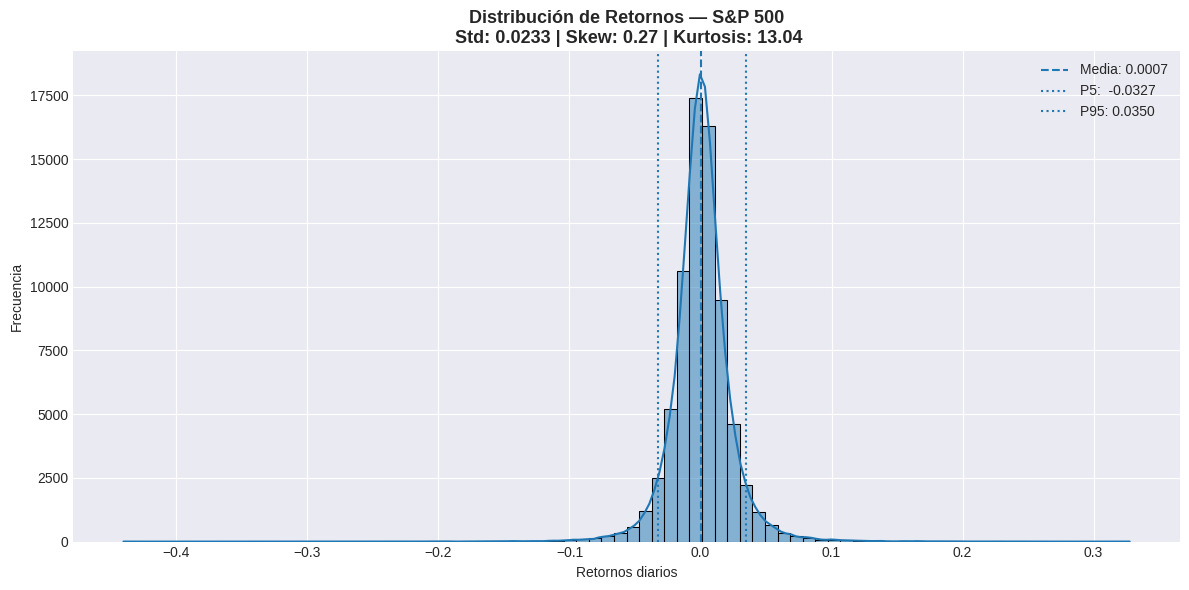


 Mapa K-Means Riesgo/Retorno...


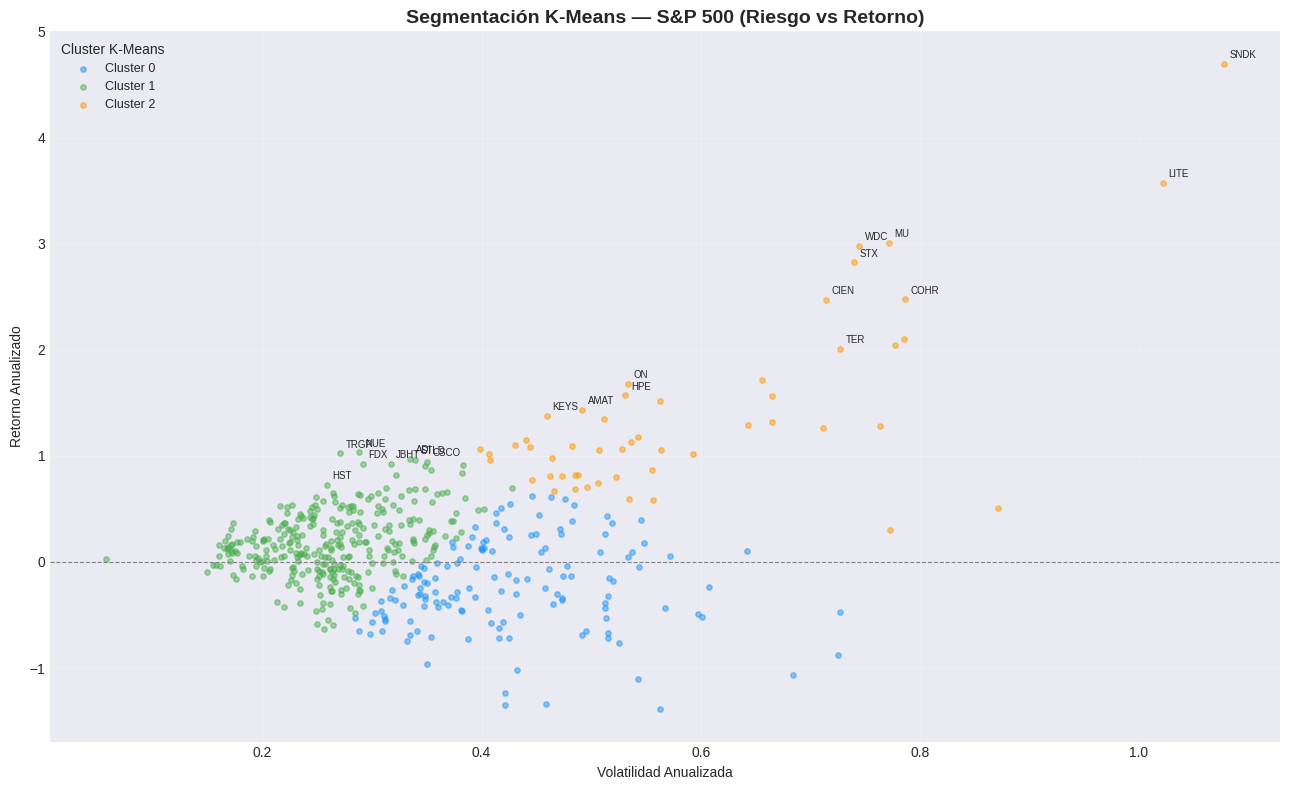


 Matriz de correlación...


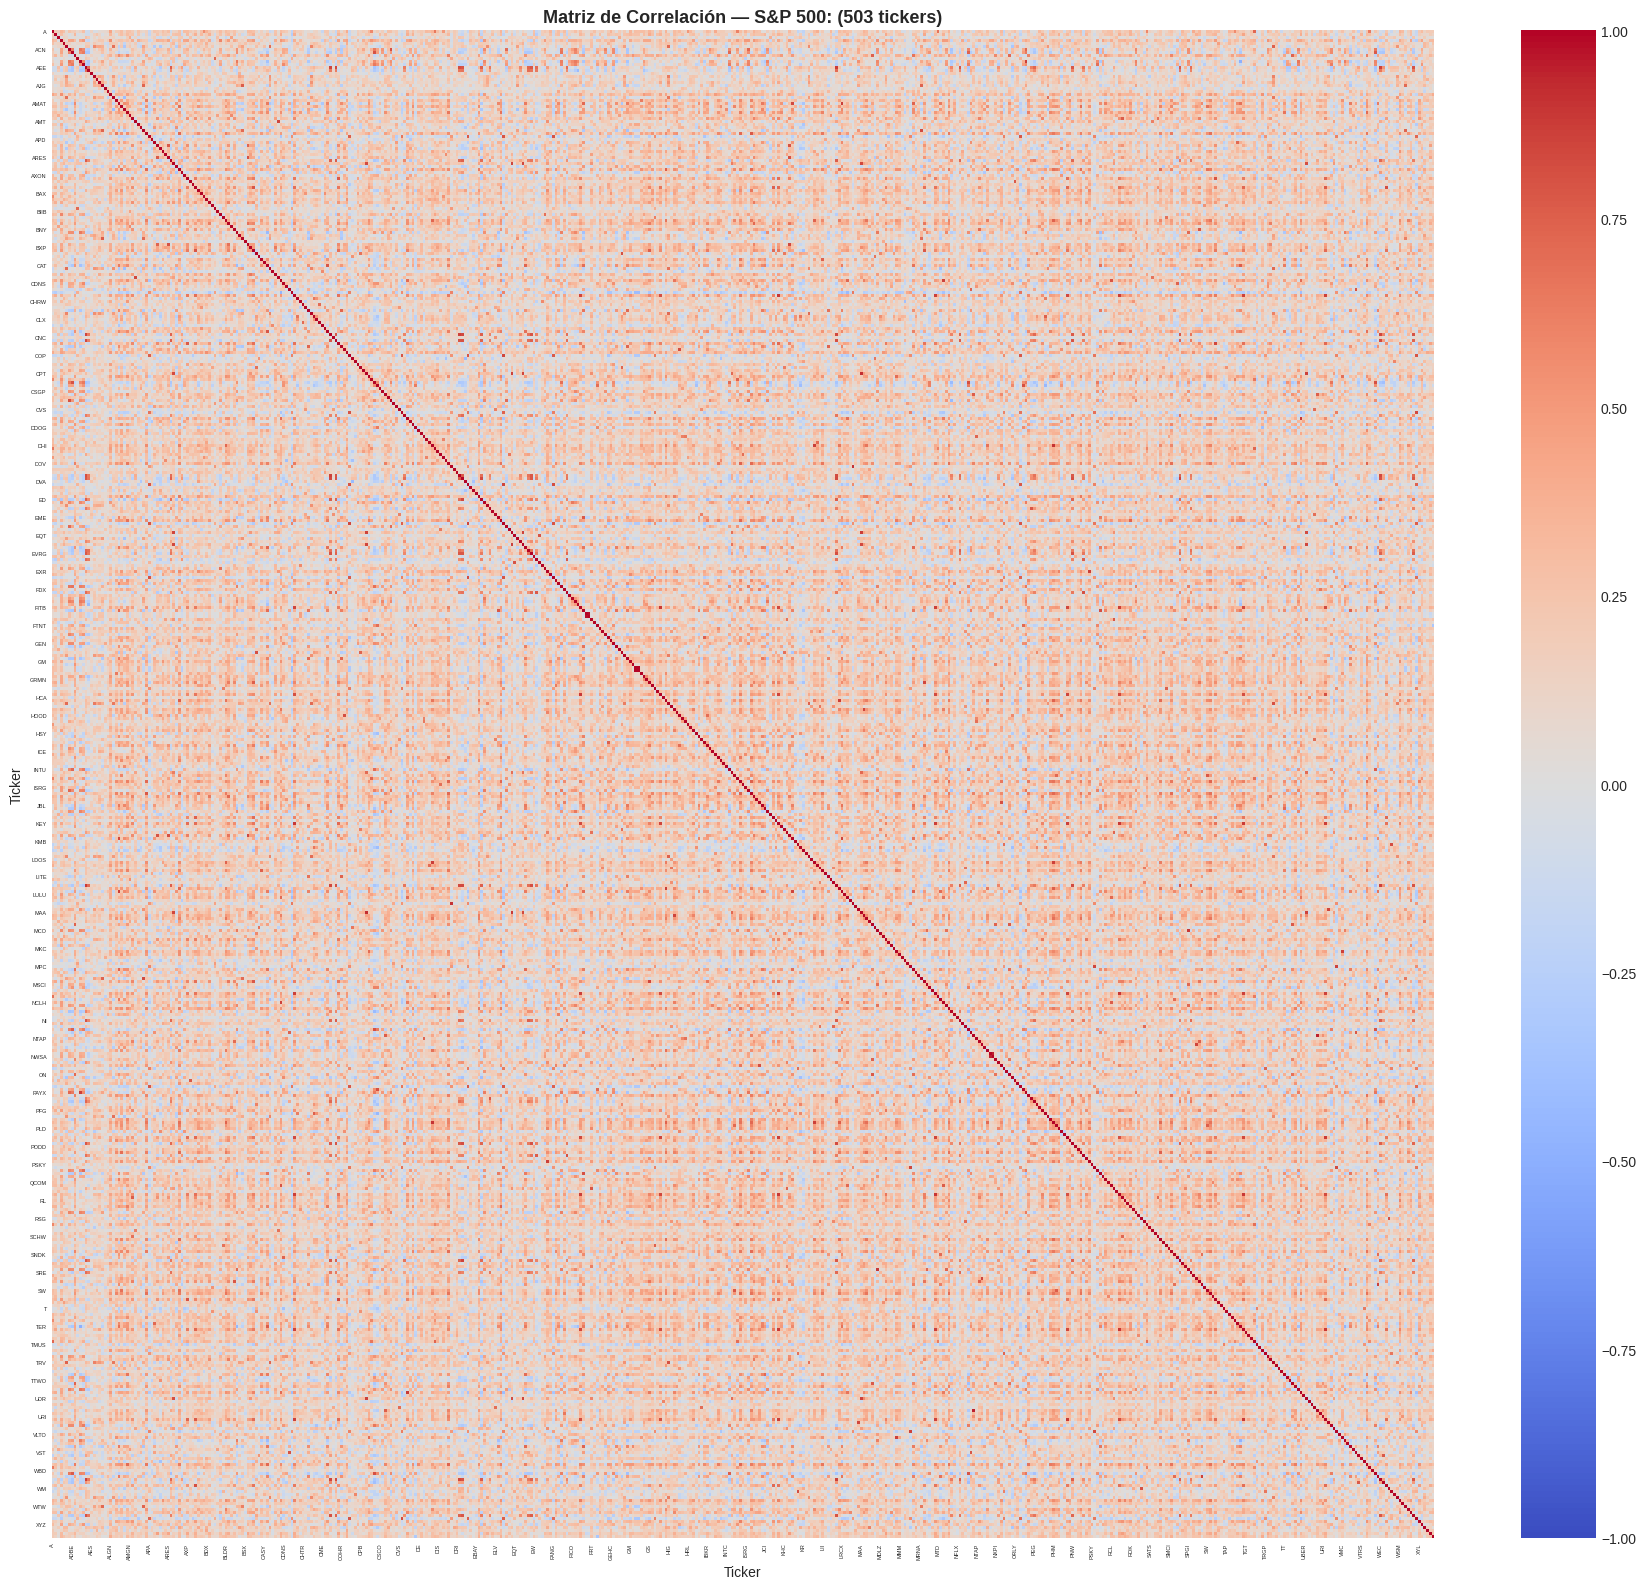


 Sharpe máximo por sector...


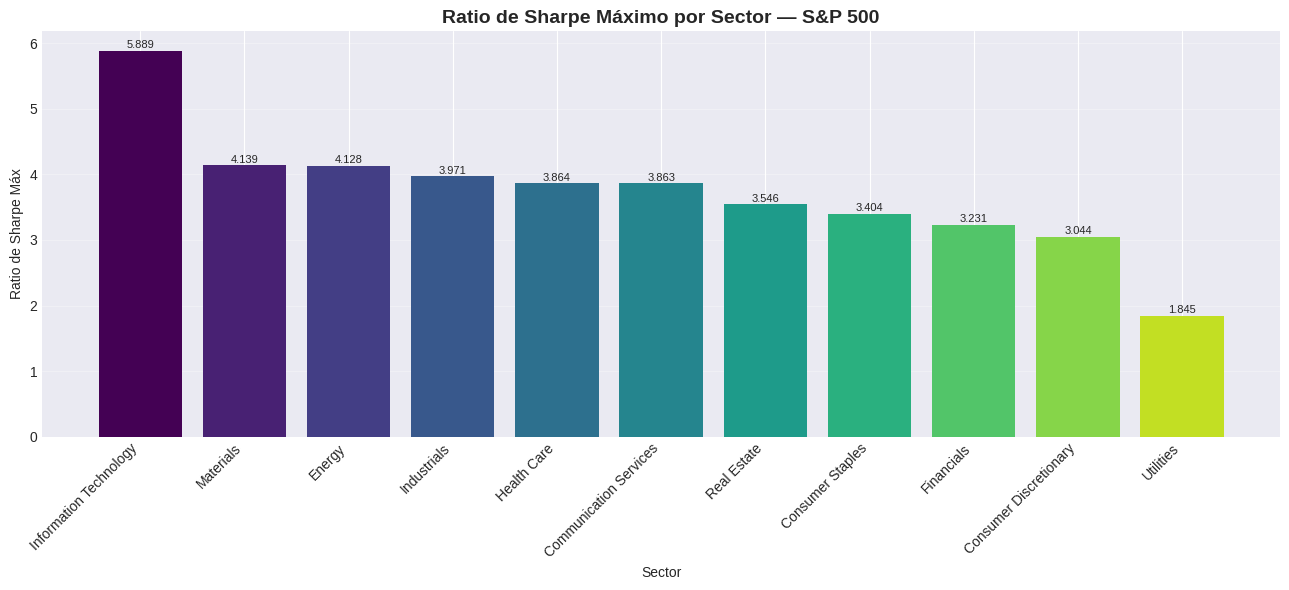


 Retorno vs Riesgo por sector...


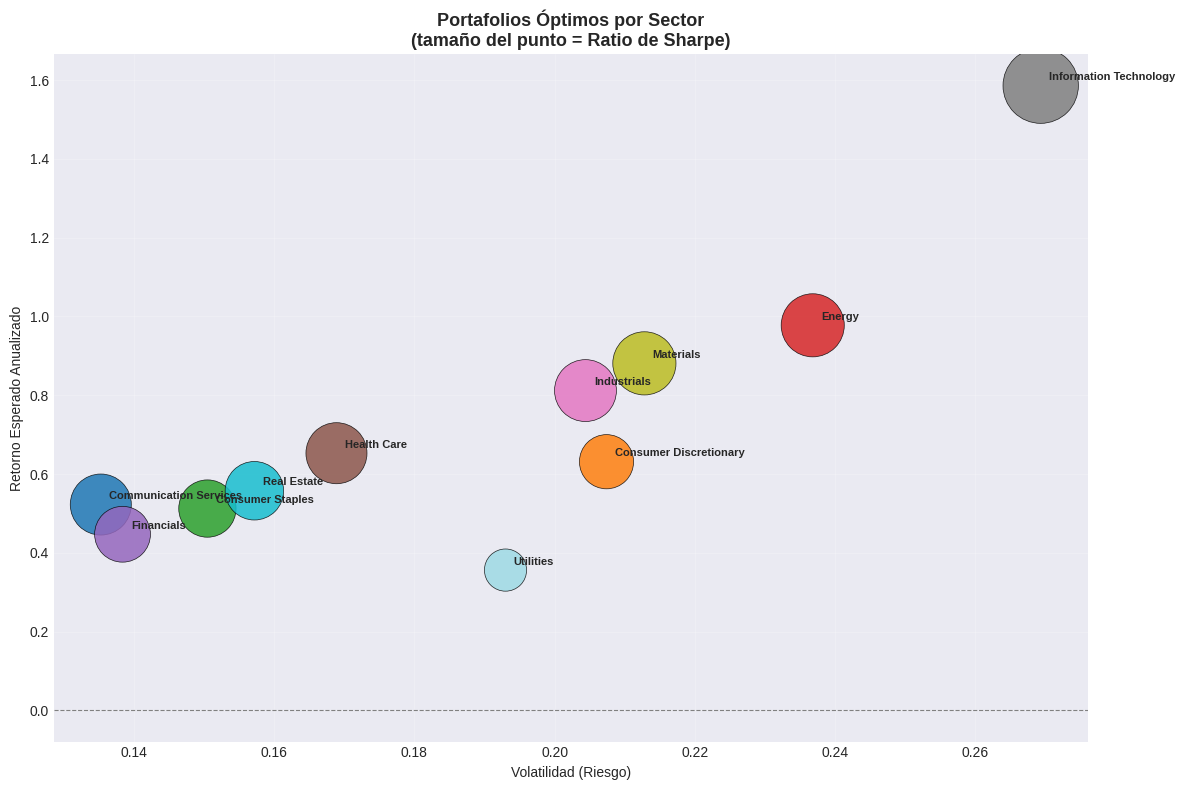


 Composición óptima por sector...}


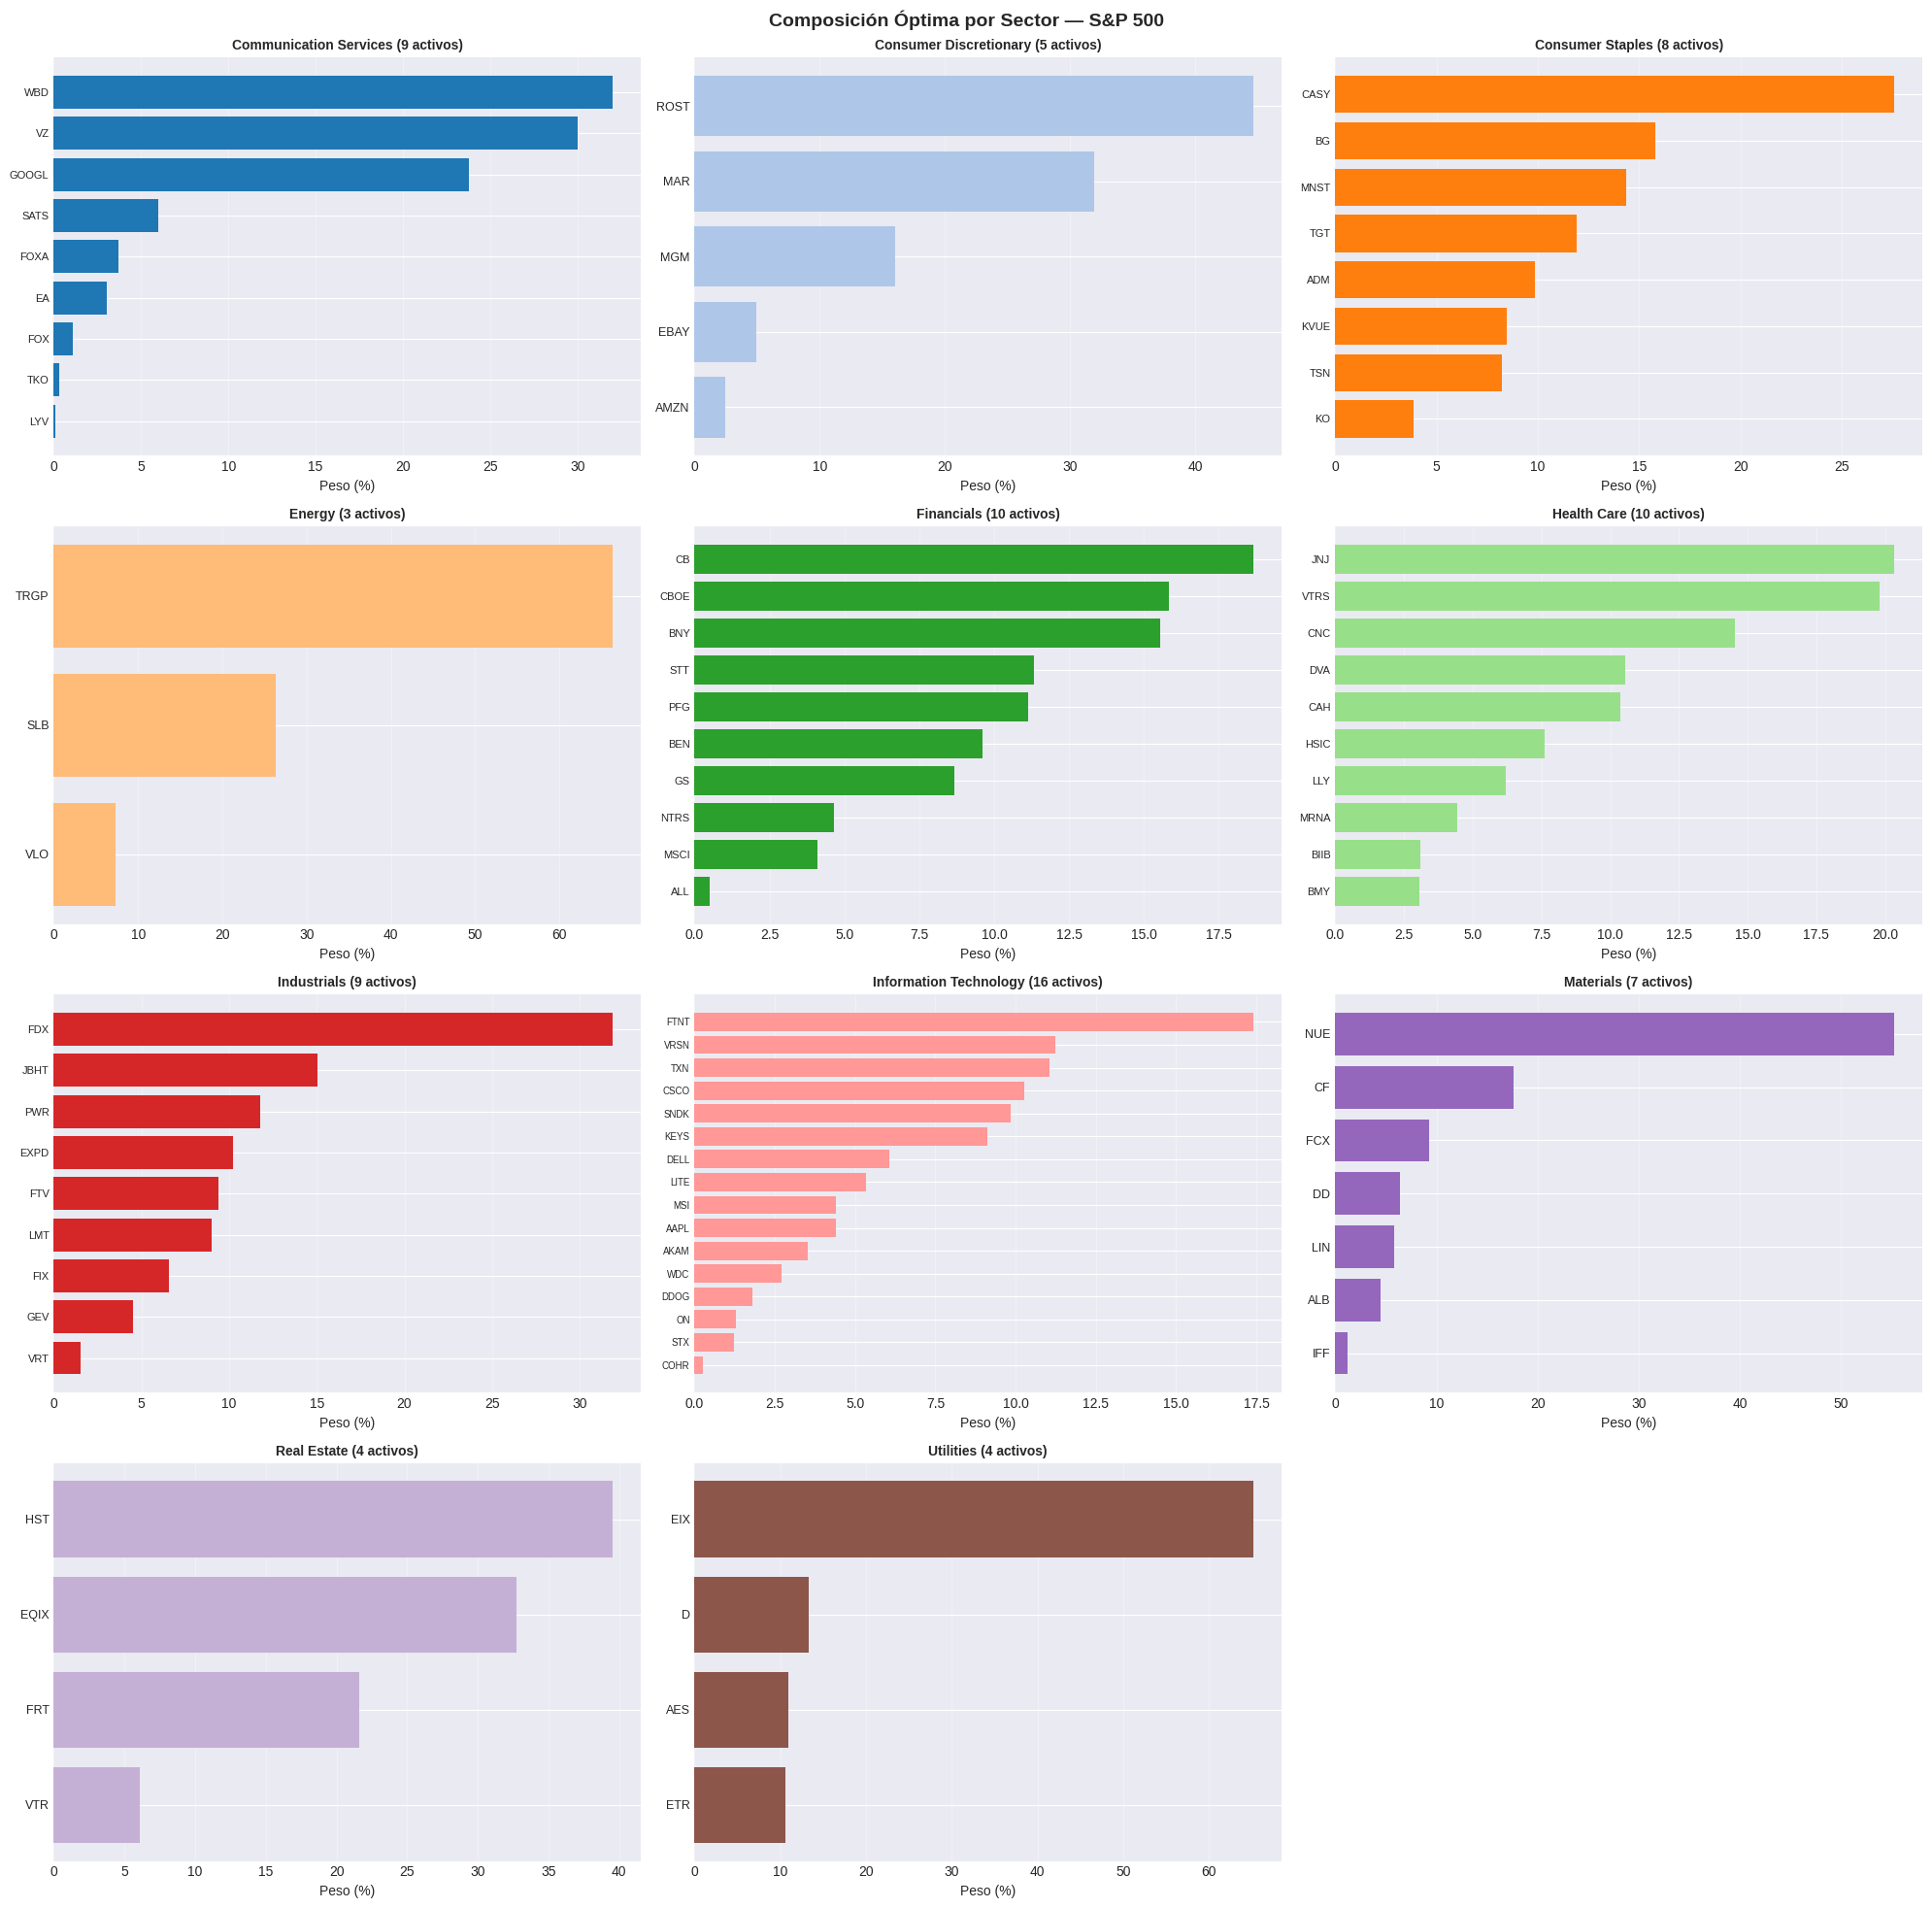


 Precisión del modelo Random Forest...


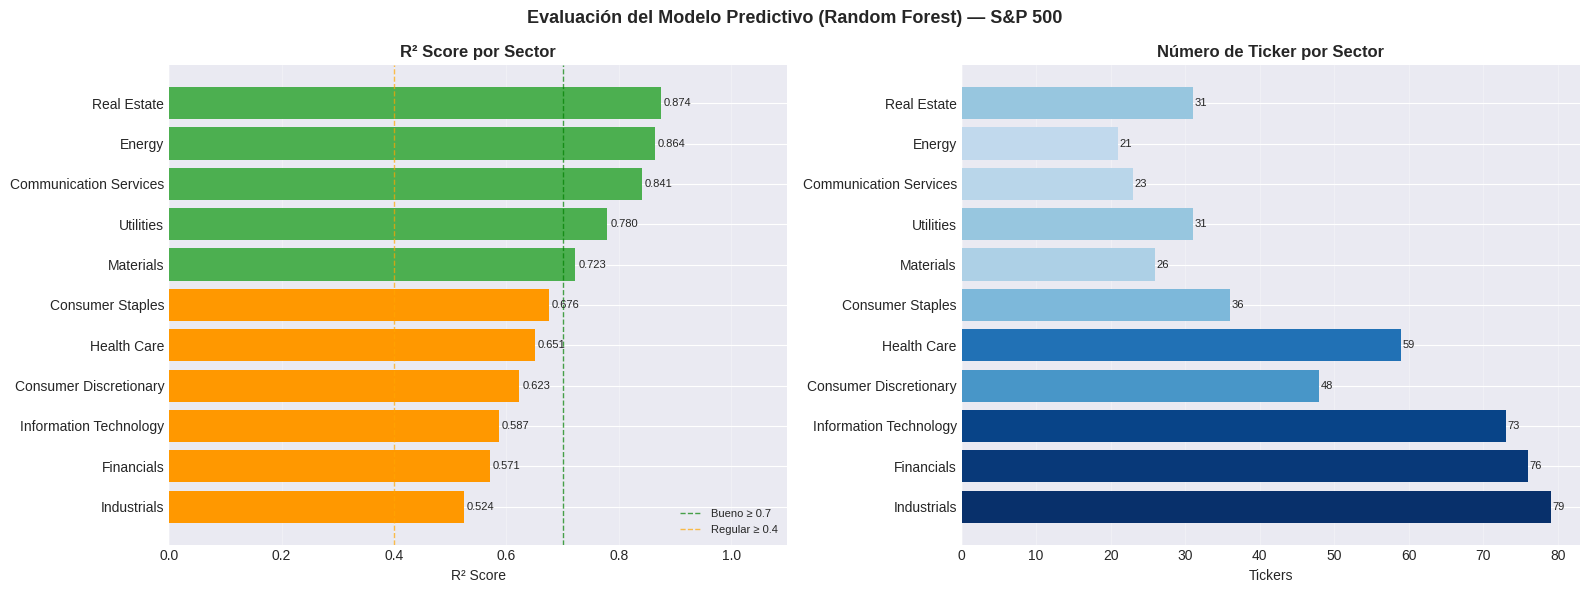


 Rendimiento acumulado: líderes por sector vs portafolio...


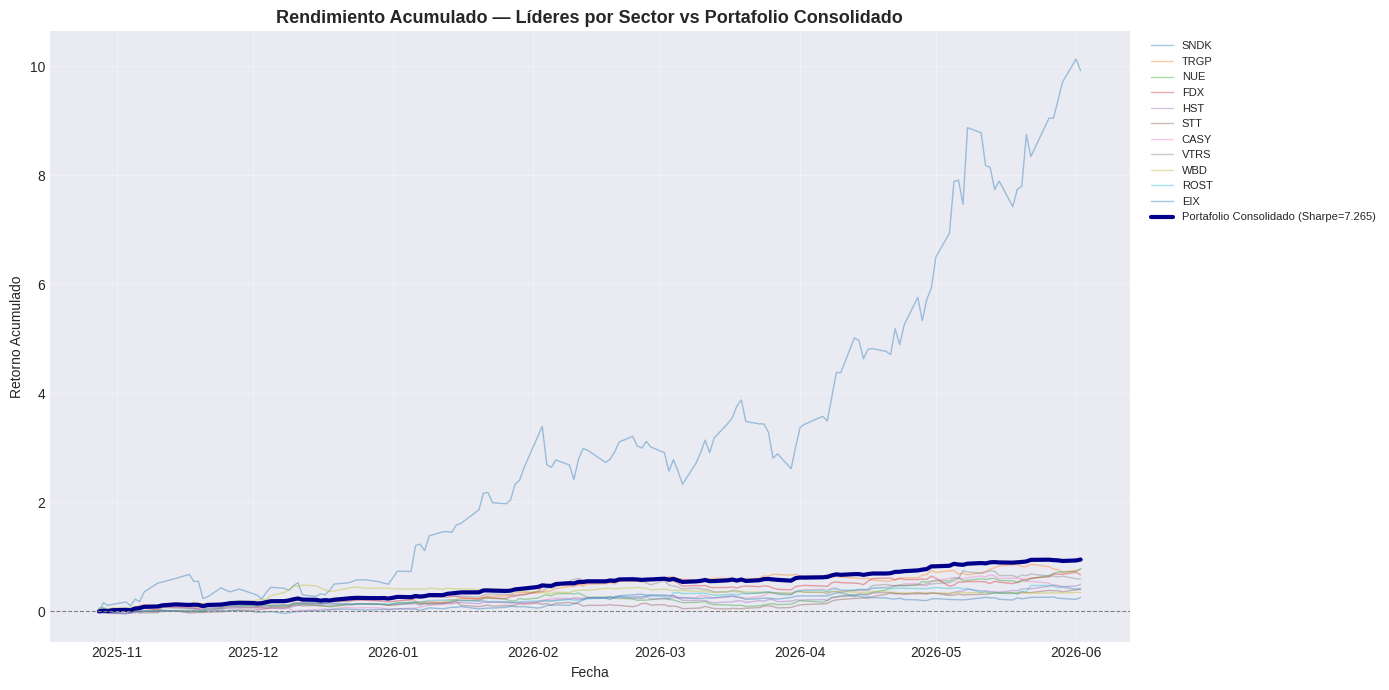


 ✓ Todas las visualizaciones generadas.


In [5]:
# ==============================================================================
# VISUALIZACIÓN — TOP 20 ACTIVOS POR RATIO DE SHARPE
# ==============================================================================
print("\n Top 20 activos por Ratio de Sharpe...")
top_sharpe = (
    df_Metricas[df_Metricas["Ratio de Sharpe"] != "N/A"]
    .assign(**{"Ratio de Sharpe": lambda d: pd.to_numeric(d["Ratio de Sharpe"], errors="coerce")})
    .sort_values("Ratio de Sharpe", ascending=False)
    .head(20)
)
colores_sector = {s: plt.cm.tab20.colors[i % 20]
                  for i, s in enumerate(top_sharpe["Sector"].unique())}
plt.figure(figsize=(14, 6))
plt.bar(top_sharpe["Ticker"], top_sharpe["Ratio de Sharpe"],
        color=[colores_sector.get(s, "steelblue") for s in top_sharpe["Sector"]])
plt.title("Top 20 Activos del S&P 500 por Ratio de Sharpe", fontsize=14, fontweight="bold")
plt.xlabel("Ticker"); plt.ylabel("Ratio de Sharpe")
plt.xticks(rotation=45, ha="right")
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colores_sector.values()]
plt.legend(handles, colores_sector.keys(), title="Sector", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — FRONTERAS EFICIENTES POR SECTOR
# ==============================================================================
print("\n Fronteras eficientes por sector...")
filas_fe   = int(np.ceil(len(datos_fe) / 3))
fig_fe, axes_fe = plt.subplots(filas_fe, 3, figsize=(18, 6 * filas_fe))
axes_fe = axes_fe.flatten()
for i_fe, (sector, d) in enumerate(datos_fe.items()):
    sc = axes_fe[i_fe].scatter(d["arr_sim"][0], d["arr_sim"][1], c=d["arr_sim"][2],
                                cmap="viridis", s=5, alpha=0.2)
    axes_fe[i_fe].scatter(d["opt_vol"], d["opt_ret"], marker="*", color="red", s=300, label="Óptimo")
    axes_fe[i_fe].set_title(f"Frontera Eficiente: {sector}\n({d['num_activos']} activos, {d['num_activos']*SIMS_POR_ACTIVO:,} sims)", fontsize=10)
    axes_fe[i_fe].set_xlabel("Riesgo (Volatilidad)")
    axes_fe[i_fe].set_ylabel("Retorno Esperado")
    axes_fe[i_fe].legend(fontsize=8)
    fig_fe.colorbar(sc, ax=axes_fe[i_fe], label="Sharpe")
for i in range(len(datos_fe), len(axes_fe)):
    axes_fe[i].axis("off")
fig_fe.suptitle("Fronteras Eficientes por Sector — S&P 500", fontsize=15, y=1.01)
fig_fe.tight_layout()
plt.show()

# ==============================================================================
# VISUALIZACIÓN — EVOLUCIÓN HISTÓRICA DE PRECIOS
# ==============================================================================
print("\n Evolución histórica de precios...")
tickers_con_datos = df_precios_sp500.columns.tolist()
df_precios_plot   = df_precios_sp500[tickers_con_datos].dropna()
plt.figure(figsize=(18, 7))
plt.plot(df_precios_plot, linewidth=0.4, alpha=0.5)
plt.title(f"Evolución Histórica de Precios — S&P 500: ({len(tickers_con_datos)} tickers)",
          fontsize=14, fontweight="bold")
plt.xlabel("Fecha"); plt.ylabel("Precio de Cierre (USD)")
plt.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — DISTRIBUCIÓN DE RETORNOS
# ==============================================================================
print("\n Distribución de retornos...")
retornos_stack = df_retornos_sp500.stack().dropna()
mean_r  = retornos_stack.mean(); std_r = retornos_stack.std()
skew_r  = skew(retornos_stack);  kurt_r = kurtosis(retornos_stack)
p5_r, p95_r = np.percentile(retornos_stack, 5), np.percentile(retornos_stack, 95)
plt.figure(figsize=(12, 6))
sns.histplot(retornos_stack, bins=80, kde=True)
plt.axvline(mean_r, linestyle="--", label=f"Media: {mean_r:.4f}")
plt.axvline(p5_r,   linestyle=":",  label=f"P5:  {p5_r:.4f}")
plt.axvline(p95_r,  linestyle=":",  label=f"P95: {p95_r:.4f}")
plt.title(f"Distribución de Retornos — S&P 500\n Std: {std_r:.4f} | Skew: {skew_r:.2f} | Kurtosis: {kurt_r:.2f}",
          fontsize=13, fontweight="bold")
plt.xlabel("Retornos diarios"); plt.ylabel("Frecuencia")
plt.legend(); plt.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — SEGMENTACIÓN K-MEANS: RIESGO VS RETORNO
# ==============================================================================
print("\n Mapa K-Means Riesgo/Retorno...")
df_viz_km = df_Metricas.copy()
df_viz_km["Retorno Anualizado"]   = pd.to_numeric(df_viz_km["Retorno Anualizado"],   errors="coerce")
df_viz_km["Volatilidad (Riesgo)"] = pd.to_numeric(df_viz_km["Volatilidad (Riesgo)"], errors="coerce")
df_viz_km = df_viz_km.dropna(subset=["Retorno Anualizado", "Volatilidad (Riesgo)"])
palette_km = {0: "#2196F3", 1: "#4CAF50", 2: "#FF9800"}
plt.figure(figsize=(13, 8))
for cl, grp in df_viz_km.groupby("Cluster"):
    plt.scatter(grp["Volatilidad (Riesgo)"], grp["Retorno Anualizado"],
                c=palette_km.get(int(cl), "gray"), s=15, alpha=0.5, label=f"Cluster {int(cl)}")
top20_km = df_viz_km.nlargest(20, "Ratio de Sharpe").index
for _, row in df_viz_km.loc[top20_km].iterrows():
    plt.annotate(row["Ticker"], (row["Volatilidad (Riesgo)"], row["Retorno Anualizado"]),
                 fontsize=7, xytext=(4, 4), textcoords="offset points")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.title("Segmentación K-Means — S&P 500 (Riesgo vs Retorno)", fontsize=14, fontweight="bold")
plt.xlabel("Volatilidad Anualizada"); plt.ylabel("Retorno Anualizado")
plt.legend(title="Cluster K-Means", fontsize=9)
plt.grid(True, alpha=0.2); plt.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — MATRIZ DE CORRELACIÓN
# ==============================================================================
print("\n Matriz de correlación...")
plt.figure(figsize=(18, 16))
sns.heatmap(df_corr_completa, cmap="coolwarm", annot=False, linewidths=0, vmin=-1, vmax=1)
plt.title(f"Matriz de Correlación — S&P 500: ({len(tickers_corr)} tickers)",
          fontsize=13, fontweight="bold")
plt.xticks(fontsize=4, rotation=90); plt.yticks(fontsize=4)
plt.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — SHARPE MÁXIMO POR SECTOR
# ==============================================================================
print("\n Sharpe máximo por sector...")
df_viz6 = tabla_portafolios_optimos.sort_values("Ratio de Sharpe Máx", ascending=False)
plt.figure(figsize=(13, 6))
bars6 = plt.bar(df_viz6["Sector"], df_viz6["Ratio de Sharpe Máx"],
                color=plt.cm.viridis([i / len(df_viz6) for i in range(len(df_viz6))]))
for bar, val in zip(bars6, df_viz6["Ratio de Sharpe Máx"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.title("Ratio de Sharpe Máximo por Sector — S&P 500", fontsize=14, fontweight="bold")
plt.xlabel("Sector"); plt.ylabel("Ratio de Sharpe Máx")
plt.xticks(rotation=45, ha="right"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — RETORNO VS RIESGO DE PORTAFOLIOS ÓPTIMOS POR SECTOR
# ==============================================================================
print("\n Retorno vs Riesgo por sector...")
df_viz7 = tabla_portafolios_optimos.copy()
df_viz7["Volatilidad (Riesgo)"] = pd.to_numeric(df_viz7["Volatilidad (Riesgo)"], errors="coerce")
df_viz7["Retorno Esperado"]     = pd.to_numeric(df_viz7["Retorno Esperado"],     errors="coerce")
df_viz7["Ratio de Sharpe Máx"] = pd.to_numeric(df_viz7["Ratio de Sharpe Máx"], errors="coerce")
plt.figure(figsize=(12, 8))
plt.scatter(df_viz7["Volatilidad (Riesgo)"], df_viz7["Retorno Esperado"],
            s=df_viz7["Ratio de Sharpe Máx"].clip(lower=0.01) * 500,
            c=range(len(df_viz7)), cmap="tab20", edgecolors="black", linewidths=0.5, alpha=0.85)
for _, row in df_viz7.iterrows():
    plt.annotate(row["Sector"], (row["Volatilidad (Riesgo)"], row["Retorno Esperado"]),
                 fontsize=8, fontweight="bold", xytext=(6, 4), textcoords="offset points")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.title("Portafolios Óptimos por Sector\n(tamaño del punto = Ratio de Sharpe)",
          fontsize=13, fontweight="bold")
plt.xlabel("Volatilidad (Riesgo)"); plt.ylabel("Retorno Esperado Anualizado")
plt.grid(True, alpha=0.2); plt.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — COMPOSICIÓN ÓPTIMA POR SECTOR (BARRAS HORIZONTALES)
# ==============================================================================

print("\n Composición óptima por sector...}")
sectores_viz8 = tabla_pesos["Sector"].unique()
filas_v8 = int(np.ceil(len(sectores_viz8) / 3))
fig8, axes8 = plt.subplots(filas_v8, 3, figsize=(20, 5 * filas_v8))
axes8 = axes8.flatten()
for i8, sector in enumerate(sectores_viz8):
    datos = tabla_pesos[(tabla_pesos["Sector"] == sector) & (tabla_pesos["Peso (%)"] > 0)].sort_values("Peso (%)", ascending=True)
    axes8[i8].barh(datos["Ticker"], datos["Peso (%)"], color=plt.cm.tab20.colors[i8 % 20])
    axes8[i8].set_title(f"{sector} ({len(datos)} activos)", fontsize=10, fontweight="bold")
    axes8[i8].set_xlabel("Peso (%)")
    axes8[i8].tick_params(axis="y", labelsize=max(5, 9 - len(datos) // 8))
    axes8[i8].grid(axis="x", alpha=0.3)
for i in range(len(sectores_viz8), len(axes8)):
    axes8[i].axis("off")
fig8.suptitle("Composición Óptima por Sector — S&P 500\n", fontsize=14, fontweight="bold")
fig8.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — PRECISIÓN DEL MODELO RANDOM FOREST
# ==============================================================================
print("\n Precisión del modelo Random Forest...")
df_viz9 = tabla_resultados_rf.sort_values("R2_Score", ascending=True)
fig9, (ax9a, ax9b) = plt.subplots(1, 2, figsize=(16, 6))
colores_r2 = ["#4CAF50" if r >= 0.7 else "#FF9800" if r >= 0.4 else "#F44336"
              for r in df_viz9["R2_Score"]]
bars9a = ax9a.barh(df_viz9["Sector"], df_viz9["R2_Score"], color=colores_r2)
ax9a.axvline(0.7, color="green",  linewidth=1, linestyle="--", alpha=0.7, label="Bueno ≥ 0.7")
ax9a.axvline(0.4, color="orange", linewidth=1, linestyle="--", alpha=0.7, label="Regular ≥ 0.4")
for bar, val in zip(bars9a, df_viz9["R2_Score"]):
    ax9a.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
              f"{val:.3f}", va="center", fontsize=8)
ax9a.set_title("R² Score por Sector", fontweight="bold")
ax9a.set_xlabel("R² Score"); ax9a.set_xlim(0, 1.1)
ax9a.legend(fontsize=8); ax9a.grid(axis="x", alpha=0.3)
ax9b.barh(df_viz9["Sector"], df_viz9["Num_Tickers"],
          color=plt.cm.Blues(df_viz9["Num_Tickers"] / df_viz9["Num_Tickers"].max()))
for bar, val in zip(ax9b.patches, df_viz9["Num_Tickers"]):
    ax9b.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
              str(val), va="center", fontsize=8)
ax9b.set_title("Número de Ticker por Sector", fontweight="bold")
ax9b.set_xlabel("Tickers"); ax9b.grid(axis="x", alpha=0.3)
fig9.suptitle("Evaluación del Modelo Predictivo (Random Forest) — S&P 500",
              fontsize=13, fontweight="bold")
fig9.tight_layout(); plt.show()

# ==============================================================================
# VISUALIZACIÓN — CONSOLIDADO — RENDIMIENTO ACUMULADO LÍDERES VS PORTAFOLIO.
# ==============================================================================
print("\n Rendimiento acumulado: líderes por sector vs portafolio...")
ret_acum_indiv = (1 + df_ret_top).cumprod() - 1
ret_acum_port  = (1 + ret_diario_top).cumprod() - 1
plt.figure(figsize=(14, 7))
for t in tickers_top:
    plt.plot(ret_acum_indiv[t], alpha=0.4, linewidth=1, label=t)
plt.plot(ret_acum_port, color="darkblue", linewidth=3,
         label=f"Portafolio Consolidado (Sharpe={sharpe_top:.3f})")
plt.title("Rendimiento Acumulado — Líderes por Sector vs Portafolio Consolidado",
          fontsize=13, fontweight="bold")
plt.xlabel("Fecha"); plt.ylabel("Retorno Acumulado")
plt.legend(fontsize=8, bbox_to_anchor=(1.01, 1))
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\n ✓ Todas las visualizaciones generadas.")

# **SELECCIÓN PERSONALIZADA DE PORTAFOLIOS**

## **1. PREPARACION DEL MENU DE SELECCION**

In [6]:
# ==============================================================================
# CARGA DE DATOS BASE PARA EL MENÚ INTERACTIVO
# ==============================================================================
print("\n Preparando menú interactivo de selección...")

df_info_base = df_Metricas.sort_values('Ticker').copy()

opciones = [
    (f"{row['Ticker']} — {row['Nombre']} ({row['Sector']})", row['Ticker'])
    for _, row in df_info_base.iterrows()
]
mapeo_sectores = dict(zip(df_info_base['Ticker'], df_info_base['Sector']))
mapeo_nombres  = dict(zip(df_info_base['Ticker'], df_info_base['Nombre']))

# ==============================================================================
# WIDGETS DEL MENÚ INTERACTIVO
# ==============================================================================
selector_activos = widgets.SelectMultiple(
    options=opciones, value=[],
    description='Tickers:',
    layout={'width': '550px', 'height': '280px'}
)

entrada_nombre = widgets.Text(
    value='', placeholder='Ej. Portafolio Tecnológico',
    description='Nombre:', layout={'width': '450px'}
)

boton_analizar = widgets.Button(
    description='Ejecutar Análisis Completo',
    button_style='success', icon='bolt'
)

salida_widget = widgets.Output()



 Preparando menú interactivo de selección...


## **2. ANALISIS DEL PORTAFOLIO PERSONALIZADO**

In [7]:
#==============================================================================
# MOTOR DE ANÁLISIS DEL PORTAFOLIO PERSONALIZADO
# ==============================================================================
def ejecutar_analisis_personalizado(b):
    with salida_widget:
        clear_output(wait=True)

        tickers_sel  = list(selector_activos.value)
        nombre_port  = entrada_nombre.value.strip() or "Portafolio Personalizado"

        if len(tickers_sel) < 2:
            print("⚠️  Seleccione al menos 2 tickers (use Ctrl/Cmd para selección múltiple).")
            return

        print(f"\n{'='*65}")
        print(f"  PROCESANDO: {nombre_port.upper()}")
        print(f"  Activos: {', '.join(tickers_sel)}")
        print(f"{'='*65}")

#===============================================================================
# Descarga y preparación
# ==============================================================================
        try:
            df_p    = descargar_precios(tickers_sel)
            df_ret  = df_p.pct_change().dropna()
        except Exception as e:
            print(f"⚠️  Error al descargar datos: {e}")
            return

        if df_ret.empty or df_ret.shape[1] < 2:
            print("⚠️  Datos insuficientes para los activos seleccionados.")
            return

        tickers_ok  = df_ret.columns.tolist()
        ret_medios  = df_ret.mean()
        mat_cov     = df_ret.cov()

#===============================================================================
# Optimización
# ==============================================================================
        print("\n Calculando asignación óptima de capital (Max Sharpe)...")
        res         = optimizar_portafolio(ret_medios, mat_cov)
        pesos_opt   = res.x
        vol_opt, ret_opt = rendimiento_portafolio(pesos_opt, ret_medios, mat_cov)
        sharpe_opt  = ret_opt / vol_opt if vol_opt > 0 else 0

#===============================================================================
# Beta CAPM
# ==============================================================================
        ret_port_diario = (df_ret * pesos_opt).sum(axis=1)
        beta_opt = calcular_beta(ret_port_diario, retornos_mercado)

#===============================================================================
# Modelo Random Forest
# ==============================================================================
        print("\n Entrenando modelo Random Forest...")
        sim_data = []
        for _ in range(1000):
            w = np.random.random(len(tickers_ok))
            w /= np.sum(w)
            pv, pr = rendimiento_portafolio(w, ret_medios, mat_cov)
            fila = dict(zip(tickers_ok, w))
            fila["Sharpe"] = pr / pv if pv > 0 else 0
            sim_data.append(fila)

        df_sim_custom  = pd.DataFrame(sim_data)
        X_ml, y_ml     = df_sim_custom[tickers_ok], df_sim_custom["Sharpe"]
        X_tr, X_te, y_tr, y_te = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)
        rf  = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_tr, y_tr)
        r2  = r2_score(y_te, rf.predict(X_te))
        mse = mean_squared_error(y_te, rf.predict(X_te))

#===============================================================================
# Resultados Cuantitativos
# ==============================================================================
        print(f"\n{'='*65}")
        print("  RESULTADOS DEL PORTAFOLIO PERSONALIZADO")
        print(f"{'='*65}")
        print(f"  Retorno Esperado Anualizado:  {ret_opt:.4f}  ({ret_opt*100:.2f}%)")
        print(f"  Volatilidad (Riesgo):         {vol_opt:.4f}  ({vol_opt*100:.2f}%)")
        print(f"  Ratio de Sharpe (Maximizado): {sharpe_opt:.4f}")
        print(f"  Beta (CAPM):                  {beta_opt:.4f}" if not np.isnan(beta_opt) else "  Beta (CAPM): N/A")
        print(f"  Precisión del Modelo (R²):    {r2:.4f}")
        print(f"  Error Cuadrático Medio (MSE): {mse:.2e}")
        print(f"\n  Asignación de Pesos Óptimos:")
        activos_excluidos = []
        for t, p in zip(tickers_ok, pesos_opt):
            if p > 0.001:
                nombre_a = mapeo_nombres.get(t, "")
                print(f"    {t:8s} ({nombre_a[:25]:25s}): {p*100:6.2f}%")
            else:
                activos_excluidos.append(t)
        if activos_excluidos:
            print(f"\n  Tickers con peso 0%: {', '.join(activos_excluidos)}")

        print("\n Generando visualizaciones...")

#===============================================================================
# Calcular métricas individuales de los tickers seleccionados
# ==============================================================================
        metricas_sel = []
        for t in tickers_ok:
            s = df_ret[t]
            r = s.mean() * DIAS_TRADING
            v = s.std()  * np.sqrt(DIAS_TRADING)
            metricas_sel.append({
                "Ticker":             t,
                "Sector":             mapeo_sectores.get(t, "N/A"),
                "Nombre":             mapeo_nombres.get(t, ""),
                "Retorno_Anualizado": r,
                "Volatilidad_Riesgo": v,
                "Sharpe":             r / v if v > 0 else 0
            })
        df_metricas_sel = pd.DataFrame(metricas_sel)

#===============================================================================
# PESOS DEL PORTAFOLIO — BARRAS HORIZONTALES
# ==============================================================================
        df_pesos_viz = pd.DataFrame({
            "Ticker":  tickers_ok,
            "Nombre":  [mapeo_nombres.get(t, "") for t in tickers_ok],
            "Peso (%)": pesos_opt * 100
        }).sort_values("Peso (%)", ascending=True)
        df_pesos_viz = df_pesos_viz[df_pesos_viz["Peso (%)"] > 0.01]

        fig_a, (ax_a1, ax_a2) = plt.subplots(1, 2, figsize=(16, max(5, len(df_pesos_viz) * 0.4 + 2)))

#===============================================================================
# - Barras horizontales de pesos
# ==============================================================================
        colores_barra = plt.cm.RdYlGn(df_pesos_viz["Peso (%)"] / df_pesos_viz["Peso (%)"].max())
        bars_a = ax_a1.barh(df_pesos_viz["Ticker"], df_pesos_viz["Peso (%)"], color=colores_barra)
        for bar, val in zip(bars_a, df_pesos_viz["Peso (%)"]):
            ax_a1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                       f"{val:.1f}%", va="center", fontsize=8)
        ax_a1.set_title(f"Pesos Óptimos — {nombre_port}", fontsize=11, fontweight="bold")
        ax_a1.set_xlabel("Peso (%)"); ax_a1.grid(axis="x", alpha=0.3)

# ===============================================================================
# - Pastel de composición
# ==============================================================================
        ax_a2.pie(
            df_pesos_viz["Peso (%)"],
            labels=df_pesos_viz["Ticker"],
            autopct="%1.1f%%", startangle=140,
            colors=plt.cm.tab20.colors[:len(df_pesos_viz)],
            wedgeprops={"edgecolor": "white", "linewidth": 1.5},
            textprops={"fontsize": max(7, 11 - len(df_pesos_viz) // 3)}
        )
        ax_a2.set_title("Distribución porcentual", fontsize=11, fontweight="bold")

        fig_a.suptitle(f"Composición Óptima (Max Sharpe) — {nombre_port.upper()}",
                       fontsize=13, fontweight="bold")
        fig_a.tight_layout(); plt.show()

# ===============================================================================
# FRONTERA EFICIENTE CON MONTE CARLO + COLORBAR DE SHARPE
# ==============================================================================
        resultados_sim = np.zeros((3, SIMS_MONTE_CARLO))
        for i in range(SIMS_MONTE_CARLO):
            w = np.random.random(len(tickers_ok))
            w /= np.sum(w)
            pv, pr = rendimiento_portafolio(w, ret_medios, mat_cov)
            resultados_sim[0, i] = pv
            resultados_sim[1, i] = pr
            resultados_sim[2, i] = pr / pv if pv > 0 else 0

        plt.figure(figsize=(12, 7))
        sc_plot = plt.scatter(
            resultados_sim[0], resultados_sim[1],
            c=resultados_sim[2], cmap="viridis", s=10, alpha=0.5
        )
        plt.colorbar(sc_plot, label="Ratio de Sharpe")
        plt.scatter(vol_opt, ret_opt, marker="*", color="red", s=500, zorder=5,
                    label=f"Óptimo — Sharpe: {sharpe_opt:.3f} | Ret: {ret_opt*100:.1f}% | Vol: {vol_opt*100:.1f}%")
        plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        plt.title(f"Frontera Eficiente — {nombre_port.upper()}", fontsize=13, fontweight="bold")
        plt.xlabel("Volatilidad (Riesgo Anualizado)"); plt.ylabel("Retorno Esperado Anualizado")
        plt.legend(fontsize=9); plt.grid(True, linestyle=":", alpha=0.4)
        plt.tight_layout(); plt.show()

#===============================================================================
# K-MEANS: MAPA DE RIESGO/RETORNO DE LOS ACTIVOS SELECCIONADOS
# ==============================================================================
        n_k = min(3, len(tickers_ok))
        sc2 = StandardScaler()
        f_s = sc2.fit_transform(df_metricas_sel[["Retorno_Anualizado", "Volatilidad_Riesgo"]])
        km2 = KMeans(n_clusters=n_k, random_state=42, n_init=10)
        df_metricas_sel["Cluster"] = km2.fit_predict(f_s)

        plt.figure(figsize=(11, 7))
        palette_c = {0: "#2196F3", 1: "#4CAF50", 2: "#FF9800"}
        for cl, grp in df_metricas_sel.groupby("Cluster"):
            plt.scatter(grp["Volatilidad_Riesgo"], grp["Retorno_Anualizado"],
                        c=palette_c.get(int(cl), "gray"), s=100, edgecolor="black",
                        alpha=0.85, label=f"Cluster {int(cl)}")
            for _, fila in grp.iterrows():
                plt.annotate(fila["Ticker"],
                             (fila["Volatilidad_Riesgo"], fila["Retorno_Anualizado"]),
                             xytext=(6, 3), textcoords="offset points",
                             fontsize=8, weight="bold")
        plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
        plt.title(f"Mapa Riesgo/Retorno (K-Means) — {nombre_port.upper()}",
                  fontsize=13, fontweight="bold")
        plt.xlabel("Volatilidad Anualizada"); plt.ylabel("Retorno Anualizado")
        plt.legend(title="Perfil de Riesgo", bbox_to_anchor=(1.05, 1))
        plt.grid(True, linestyle=":", alpha=0.5)
        plt.tight_layout(); plt.show()

#===============================================================================
# MATRIZ DE CORRELACIÓN
# ==============================================================================
        corr_sel = df_ret.corr()
        fig_size = max(8, len(tickers_ok))
        plt.figure(figsize=(fig_size, fig_size - 1))
        sns.heatmap(corr_sel, annot=True, cmap="coolwarm", fmt=".2f",
                    linewidths=0.5, vmin=-1, vmax=1,
                    annot_kws={"size": max(7, 11 - len(tickers_ok) // 4)})
        plt.title(f"Correlación entre Activos — {nombre_port.upper()}",
                  fontsize=13, fontweight="bold")
        plt.tight_layout(); plt.show()

        df_rv = df_metricas_sel.sort_values("Sharpe", ascending=False)
        colores_rv = plt.cm.RdYlGn(
            (df_rv["Sharpe"] - df_rv["Sharpe"].min()) /
            (df_rv["Sharpe"].max() - df_rv["Sharpe"].min() + 1e-9)
        )
        plt.figure(figsize=(11, 7))
        sc_rv = plt.scatter(
            df_rv["Volatilidad_Riesgo"], df_rv["Retorno_Anualizado"],
            c=df_rv["Sharpe"], cmap="RdYlGn", s=150,
            edgecolors="black", linewidths=0.5, zorder=3
        )
        plt.colorbar(sc_rv, label="Ratio de Sharpe")
        for _, row in df_rv.iterrows():
            plt.annotate(
                f"{row['Ticker']}\n({row['Sharpe']:.2f})",
                (row["Volatilidad_Riesgo"], row["Retorno_Anualizado"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=8, weight="bold"
            )

#===============================================================================
# Portafolio óptimo en este mismo gráfico
# ==============================================================================
        plt.scatter(vol_opt, ret_opt, marker="*", color="red", s=400, zorder=5,
                    label="Portafolio Óptimo")
        plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        plt.title(f"Retorno vs Riesgo por Activo — {nombre_port.upper()}",
                  fontsize=13, fontweight="bold")
        plt.xlabel("Volatilidad (Riesgo)"); plt.ylabel("Retorno Anualizado")
        plt.legend(fontsize=9); plt.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

#===============================================================================
# RENDIMIENTO ACUMULADO — ACTIVOS INDIVIDUALES vs PORTAFOLIO ÓPTIMO
# ==============================================================================
        ret_acum_i = (1 + df_ret).cumprod() - 1
        ret_acum_p = (1 + ret_port_diario).cumprod() - 1

        plt.figure(figsize=(14, 7))
        for t in tickers_ok:
            plt.plot(ret_acum_i[t], alpha=0.35, linewidth=1, label=t)
        plt.plot(ret_acum_p, color="darkblue", linewidth=3,
                 label=f"Portafolio Óptimo (Sharpe={sharpe_opt:.3f})")
        plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        plt.title(f"Rendimiento Acumulado — {nombre_port.upper()}",
                  fontsize=13, fontweight="bold")
        plt.xlabel("Fecha"); plt.ylabel("Retorno Acumulado")
        plt.legend(fontsize=8, bbox_to_anchor=(1.01, 1))
        plt.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

        print(f"\n✓ Análisis completado — 6 visualizaciones generadas para: {nombre_port}")

#===============================================================================
# Asignar el evento al botón
# ==============================================================================
boton_analizar.on_click(ejecutar_analisis_personalizado)

## **3. VISUALIZACIONES DE PORTAFOLIO PERSONALIZADO**

## **EXPORTACIÓN  A GOOGLE SHEETS (MANUAL)**

In [8]:
# ==============================================================================
# EXPORTACIÓN  A GOOGLE SHEETS
# ==============================================================================
def exportar_seleccion_a_sheets(tabla_frontera_df, tabla_sims_df):
    """
    Exporta los resultados de la selección personalizada al Google Sheet maestro.
    - tabla_frontera_df : resultado óptimo  → va a Sheets.
    - tabla_sims_df     : simulaciones completas          → CSV a Drive.
    Llamar esta función después de ejecutar el análisis interactivo.
    """
    print(f"[Export] Exportando selección personalizada a '{NOMBRE_SHEET}'...")
    try:
        sh_exp = gc.open(NOMBRE_SHEET)
    except gspread.exceptions.SpreadsheetNotFound:
        sh_exp = gc.create(NOMBRE_SHEET)

    # Resultado óptimo
    exportar_a_sheet(sh_exp, tabla_frontera_df, "Portafolio_Personalizado_Optimo")

    # Simulaciones: solo métricas (sin columnas de peso por ticker)
    cols_metricas = ["Portafolio", "Retorno Esperado", "Volatilidad", "Ratio de Sharpe"]
    cols_presentes = [c for c in cols_metricas if c in tabla_sims_df.columns]
    exportar_a_sheet(sh_exp, tabla_sims_df[cols_presentes], "Simulaciones_Custom_Metricas")

    # Detalle completo con pesos → CSV a Drive
    exportar_csv_a_drive(tabla_sims_df, "Simulaciones_Portafolio_Custom_Detalle.csv")

    print(f"\n✓ Exportación completada. URL: {sh_exp.url}")

# ==============================================================================
# RENDERIZADO DEL MENÚ INTERACTIVO
# ==============================================================================
print("\n" + "="*65)
print("  — PORTAL DE SELECCIÓN DE PORTAFOLIO PERSONALIZADO")
print("  Instrucción: Seleccione activos con Ctrl/Cmd + clic")
print("="*65)

display(entrada_nombre)
display(selector_activos)
display(boton_analizar)
display(salida_widget)


  — PORTAL DE SELECCIÓN DE PORTAFOLIO PERSONALIZADO
  Instrucción: Seleccione activos con Ctrl/Cmd + clic


Text(value='', description='Nombre:', layout=Layout(width='450px'), placeholder='Ej. Portafolio Tecnológico')

SelectMultiple(description='Tickers:', layout=Layout(height='280px', width='550px'), options=(('A — Agilent Te…

Button(button_style='success', description='Ejecutar Análisis Completo', icon='bolt', style=ButtonStyle())

Output()